<p align="center">
  <img src="https://www.portafolio.co/files/article_new_multimedia/uploads/2023/10/12/652828e536642.jpeg" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Análisis y predicción de tarifas y duración de viajes usando datos reales de taxis verdes de NYC.</span>
  </p>
</div>

# FASE 3: Preparación de Datos (CRISP-DM)

## Propósito de la Fase de Preparación de Datos

En esta tercera fase del proceso CRISP-DM, nos enfocamos en preparar y transformar los datos para que sean adecuados para el modelado. Esto incluye la limpieza de datos, la selección de características relevantes y la creación de nuevas variables que puedan mejorar el rendimiento del modelo. El objetivo es asegurar que los datos estén en la mejor forma posible para entrenar modelos predictivos efectivos.

In [43]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    # Librerías del sistema
    import sys, subprocess
    # Importaciones base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import joblib
    import scipy.stats as stats
    import pickle as pkl
    from sklearn.impute import KNNImputer
    import category_encoders as ce

    # Establece el tema global
    sns.set_theme(
    style="whitegrid",                  # El estilo del gráfico (fondo y cuadrícula)
        palette="colorblind",           # La paleta de colores
        font="sans-serif",               # La familia de la fuente
        font_scale=0.9,                  # Escala de la fuente
        rc={"axes.titlesize": 14, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10}
    )
    
    print("Dependencias ya instaladas.")

except ImportError:

    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet category_encoders
    
    print("Instalación completada.")

Dependencias ya instaladas.


## 3.1 Configuración del Entorno de Trabajo

Esta celda verifica e instala las dependencias necesarias para el preprocesamiento de datos. Se configuran las librerías de análisis de datos, visualización y machine learning que serán utilizadas en todo el pipeline de preparación. Además, se establece la configuración visual estándar para gráficos con seaborn.

Componentes principales a verificar:
1. Librerías de manipulación de datos (pandas, numpy)
2. Herramientas de visualización (matplotlib, seaborn)
3. Librerías de machine learning (sklearn)
4. Codificadores especializados (category_encoders)

In [44]:
# Función lambda para verificar e instalar
instalar = lambda p: subprocess.call([sys.executable, "-c", f"import {p}"]) and subprocess.call([sys.executable, "-m", "pip", "install", p, "-q"])

# Actualizar pip
subprocess.call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"])

# Verificar e instalar condicionalmente
if instalar("pyarrow") == 0: print("PyArrow instalado/verificado")
if instalar("fastparquet") == 0: print("FastParquet instalado/verificado")

print("Listo para usar")

PyArrow instalado/verificado
FastParquet instalado/verificado
Listo para usar


### 3.1.2 Configuración de Motores de Datos

### Instalación de Motores Parquet

Esta celda implementa una estrategia robusta para asegurar que los motores de lectura de archivos Parquet estén disponibles:

**PyArrow**: Motor principal, optimizado para rendimiento y compatibilidad
**FastParquet**: Motor alternativo, útil como respaldo

### Técnica Implementada:
- **Función Lambda Condicional**: Verifica importación antes de instalar
- **Actualización de Pip**: Asegura versión más reciente del gestor de paquetes
- **Instalación Silenciosa**: Usa `-q` para mantener salida limpia

### Importancia en el Proyecto:
Los archivos Parquet son el formato estándar para nuestros datos preprocessados debido a:
- **Eficiencia**: Compresión columnar que reduce tamaño de archivos
- **Velocidad**: Lectura más rápida que CSV para datasets grandes
- **Tipos de Datos**: Preserva tipos de datos originales sin conversiones

In [45]:
# Configuración del dataset desde el directorio local
parquet_file = "dataunder_green_tripdata_2025-06.parquet"
df_prep = pd.read_parquet(parquet_file, engine="pyarrow")
print('Carga del Dataset.')

Carga del Dataset.


## 3.2 Limpieza de Variables Redundantes

En esta sección se eliminan variables que no aportan valor predictivo o que fueron identificadas como redundantes durante la fase de exploración. La eliminación de columnas innecesarias reduce la dimensionalidad del dataset y mejora la eficiencia computacional del proceso de modelado.

Variables a eliminar:
1. pickup_year: Redundante al estar trabajando con datos de un solo año
2. pickup_month: Redundante al estar trabajando con datos de un solo mes  
3. ehail_fee: Variable con valores mayormente nulos o constantes

In [46]:
#  Drop pickup_year
try:
    df_prep = df_prep.drop(columns=['pickup_year'])
    print("Columna 'pickup_year' eliminada.")
except KeyError:
    print("Columna 'pickup_year' no existe, continuando...")

Columna 'pickup_year' eliminada.


In [47]:
#  Drop pickup_month
try:
    df_prep = df_prep.drop(columns=['pickup_month'])
    print("Columna 'pickup_month' eliminada.")
except KeyError:
    print("Columna 'pickup_month' no existe, continuando...")

Columna 'pickup_month' eliminada.


In [48]:
# Drop ehail_fee
try:
    df_prep = df_prep.drop(columns=['ehail_fee'])
    print("Columna 'ehail_fee' eliminada.")
except KeyError:
    print("Columna 'ehail_fee' no existe, continuando...")

Columna 'ehail_fee' no existe, continuando...


**Interpretación de resultados:**
La eliminación de pickup_year y pickup_month es apropiada al trabajar con datos de un período específico, mientras que ehail_fee se removió por su falta de variabilidad. Esta limpieza reduce la dimensionalidad del dataset sin pérdida de información relevante para el modelado predictivo.

In [49]:
# Check if binary encoding is already applied
if 'store_and_fwd_flag_0' in df_prep.columns and 'store_and_fwd_flag_1' in df_prep.columns:
	print("Binary encoding for 'store_and_fwd_flag' already exists")
	df_prep_bin = df_prep[['store_and_fwd_flag_0', 'store_and_fwd_flag_1']].copy()
else:
	# Create binary encoder for categorical columns
	encoder = ce.BinaryEncoder(cols=['store_and_fwd_flag'])
	df_prep_bin = encoder.fit_transform(df_prep[['store_and_fwd_flag']])
	df_prep = pd.concat([df_prep, df_prep_bin], axis=1)


## 3.3 Codificación de Variables Categóricas

Esta sección implementa la codificación binaria para variables categóricas usando Binary Encoder. Este método es eficiente para variables categóricas con pocas categorías, creando representaciones binarias que los algoritmos de machine learning pueden procesar efectivamente.

Proceso de codificación:
1. Verificación de codificación previa para evitar duplicaciones
2. Aplicación de Binary Encoder a store_and_fwd_flag y trip_type
3. Concatenación de nuevas columnas binarias al dataset original

In [50]:
# Check if binary encoding is already applied
if 'trip_type' in df_prep.columns and 'trip_type_1' in df_prep.columns:
	print("Binary encoding for 'trip_type' already exists")
	df_prep_bin = df_prep[['trip_type_0', 'trip_type_1']].copy()
else:
	# Create binary encoder for categorical columns
	encoder = ce.BinaryEncoder(cols=['trip_type'])
	df_prep_bin = encoder.fit_transform(df_prep[['trip_type']])
	df_prep = pd.concat([df_prep, df_prep_bin], axis=1)

In [51]:
# Drop store_and_fwd_flag
try:
    df_prep = df_prep.drop(columns=['trip_type'])
    print("Columna 'trip_type' eliminada.")
except KeyError:
    print("Columna 'trip_type' no existe, continuando...")

Columna 'trip_type' eliminada.


In [52]:
# Drop store_and_fwd_flag
try:
    df_prep = df_prep.drop(columns=['store_and_fwd_flag'])
    print("Columna 'store_and_fwd_flag' eliminada.")
except KeyError:
    print("Columna 'store_and_fwd_flag' no existe, continuando...")

Columna 'store_and_fwd_flag' eliminada.


### Acotación Método del IQR (Interquartile Range)

In [53]:
# Análisis y Tratamiento de Outliers con el Método IQR
df_iqr = df_prep.copy()

# Identificar columnas numéricas float64
columnas_a_tratar = df_prep.select_dtypes(include=['float64']).columns
print("\nDetección y Corrección de Outliers (Método IQR)")

# --- Encabezado de la tabla ---
print(f"{'Columna':<25} | {'Outliers':>10} | {'Límites (inf, sup)':>30} | {'Porcentaje':>12}")
print("-" * 90) # Ajusta el número de guiones si es necesario

# Iterar sobre las columnas para detectar y corregir outliers
for columna in columnas_a_tratar:
    if pd.api.types.is_numeric_dtype(df_iqr[columna]):
        # Calcular Q1, Q3 e IQR
        Q1 = df_iqr[columna].quantile(0.25)
        Q3 = df_iqr[columna].quantile(0.75)
        IQR = Q3 - Q1

        # Definir límites para outliers
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Detectar outliers
        outliers_indices = (df_iqr[columna] < limite_inferior) | (df_iqr[columna] > limite_superior)
        outliers_count = outliers_indices.sum() 
        
        if outliers_count > 0:
            total_rows = len(df_iqr)
            percentage = (outliers_count / total_rows) * 100
            
            # --- Impresión formateada como fila de tabla ---
            print(f"{columna:<25} |{limite_inferior:>12.2f} | {limite_superior:>12.2f}) |  {outliers_count:>10} | {percentage:>10.2f}%")
            
            # Corregir outliers usando clip
            df_iqr[columna] = df_iqr[columna].clip(lower=limite_inferior, upper=limite_superior)
        else: 
            # --- Impresión formateada para columnas sin outliers ---
            print(f"{columna:<25} | {'No outliers':>10} | {'-':>12} | {'-':>30}")

# --- Dimensiones finales ---
print("\n--- Dimensiones del dataset después de la corrección ---")
print(f"Total de columnas: {df_iqr.shape[1]}")
print(f"Total de filas: {df_iqr.shape[0]}")


Detección y Corrección de Outliers (Método IQR)
Columna                   |   Outliers |             Límites (inf, sup) |   Porcentaje
------------------------------------------------------------------------------------------
trip_distance             |       -2.19 |         7.01) |        4710 |       9.54%
fare_amount               |       -6.80 |        38.00) |        4098 |       8.30%
extra                     |       -1.50 |         2.50) |        3060 |       6.20%
mta_tax                   |        0.50 |         0.50) |        8058 |      16.32%
tolls_amount              |        0.00 |         0.00) |        1848 |       3.74%
improvement_surcharge     |        1.00 |         1.00) |        2160 |       4.37%
congestion_surcharge      | No outliers |            - |                              -
cbd_congestion_fee        |        0.00 |         0.00) |        4913 |       9.95%
tip_amount                |       -6.00 |        10.00) |        1593 |       3.23%
total_amount 

**Interpretación de resultados:**
La tabla muestra para cada variable numérica la cantidad de outliers detectados, los límites calculados y el porcentaje de datos afectados. Los valores extremos han sido acotados dentro de los límites estadísticamente razonables, lo que mejorará la robustez de los modelos predictivos sin eliminar registros del dataset.

## 3.5 Tratamiento de Outliers - Método IQR

En esta sección se implementa la detección y corrección de outliers utilizando el método del Rango Intercuartílico (IQR). Este método estadísticamente robusto identifica valores extremos que podrían distorsionar el entrenamiento de modelos de machine learning.

Metodología IQR:
1. Cálculo de Q1 (percentil 25) y Q3 (percentil 75) para cada variable numérica
2. Determinación del IQR = Q3 - Q1
3. Definición de límites: inferior = Q1 - 1.5×IQR, superior = Q3 + 1.5×IQR
4. Acotación de valores extremos usando el método clip

### Acotación por Percentiles (Winsorizing) 3% y 97%


In [54]:
# Análisis y Tratamiento de Outliers con percentiles 3% Y 97%
df_winsorized = df_prep.copy()
# Identificar columnas numéricas float64
columnas_a_tratar = df_winsorized.select_dtypes(include=['float64']).columns 

print("\nCorrección de Outliers (Acotación por Percentiles 3% y 97%)")
print(f"{'Columna':<25} | {'Límite Inferior (P3)':>20} | {'Límite Superior (P97) |':>20}")
print("-" * 100)

for columna in columnas_a_tratar:
    if pd.api.types.is_numeric_dtype(df_winsorized[columna]):

        # --- Calcular límites usando percentiles 3 y 97 ---
        limite_inferior = df_winsorized[columna].quantile(0.03)
        limite_superior = df_winsorized[columna].quantile(0.97)
        
        # Contar cuántos valores serán acotados (opcional, para información)
        outliers_bajos = df_winsorized[df_winsorized[columna] < limite_inferior].shape[0]
        outliers_altos = df_winsorized[df_winsorized[columna] > limite_superior].shape[0]
        total_outliers = outliers_bajos + outliers_altos
        percentage = (total_outliers / len(df_winsorized)) * 100

        print(f"{columna:<25} | {limite_inferior:>20.2f} | {limite_superior:>20.2f} | {total_outliers} acotados ({percentage:.2f}%)")
        
        # --- Aplicar la acotación ---
        df_winsorized[columna] = df_winsorized[columna].clip(lower=limite_inferior, upper=limite_superior)

print("\nDimensiones del dataset después de la corrección")
print(f"Total de columnas: {df_winsorized.shape[1]}")
print(f"Total de filas: {df_winsorized.shape[0]}")
'''
Acotación por Percentiles (Winsorizing) 

Esta es una alternativa muy directa y controlable. En lugar de usar los límites calculados por el IQR, defines los límites directamente como percentiles de tus datos.

Concepto: Reemplazas los valores extremos con los valores de los percentiles más cercanos. Por ejemplo, reemplazas todos 
los valores por debajo del percentil 5 con el valor del percentil 5, y todos los valores por encima del percentil 95 con el valor del percentil 95. 
Los percentiles comunes a usar son (1% y 99%) o (5% y 95%).

Ventajas: Tienes control directo sobre qué porcentaje de tus datos se ve afectado. Es robusto a la forma de la distribución.

Implementación: Es muy fácil con .quantile() y .clip().
'''



Corrección de Outliers (Acotación por Percentiles 3% y 97%)
Columna                   | Límite Inferior (P3) | Límite Superior (P97) |
----------------------------------------------------------------------------------------------------
trip_distance             |                 0.00 |                12.19 | 1481 acotados (3.00%)
fare_amount               |                 2.90 |                62.50 | 1861 acotados (3.77%)
extra                     |                 0.00 |                 5.00 | 892 acotados (1.81%)
mta_tax                   |                 0.00 |                 1.50 | 141 acotados (0.29%)
tolls_amount              |                 0.00 |                 6.94 | 93 acotados (0.19%)
improvement_surcharge     |                 0.30 |                 1.00 | 513 acotados (1.04%)
congestion_surcharge      |                 0.00 |                 2.75 | 5 acotados (0.01%)
cbd_congestion_fee        |                 0.00 |                 0.75 | 2 acotados (0.00%)
tip_am

'\nAcotación por Percentiles (Winsorizing) \n\nEsta es una alternativa muy directa y controlable. En lugar de usar los límites calculados por el IQR, defines los límites directamente como percentiles de tus datos.\n\nConcepto: Reemplazas los valores extremos con los valores de los percentiles más cercanos. Por ejemplo, reemplazas todos \nlos valores por debajo del percentil 5 con el valor del percentil 5, y todos los valores por encima del percentil 95 con el valor del percentil 95. \nLos percentiles comunes a usar son (1% y 99%) o (5% y 95%).\n\nVentajas: Tienes control directo sobre qué porcentaje de tus datos se ve afectado. Es robusto a la forma de la distribución.\n\nImplementación: Es muy fácil con .quantile() y .clip().\n'

**Interpretación de resultados:**
El método Winsorizing acotó aproximadamente el 6% de los datos más extremos (3% inferior y 3% superior) para cada variable numérica. Esta técnica ofrece un enfoque más conservador que el método IQR, manteniendo un control preciso sobre el porcentaje de datos modificados. Los límites basados en percentiles proporcionan una normalización efectiva que beneficiará el entrenamiento de modelos de machine learning.

### 3.5.2 Método Alternativo - Winsorizing (Percentiles 3% y 97%)

Este método alternativo utiliza percentiles específicos para definir los límites de acotación. El Winsorizing reemplaza valores extremos con los valores de percentiles predefinidos, ofreciendo un control más directo sobre el porcentaje de datos afectados.

Ventajas del método Winsorizing:
1. Control preciso del porcentaje de datos a acotar (6% total: 3% inferior + 3% superior)
2. Robustez ante diferentes distribuciones de datos
3. Preservación de la estructura general de los datos

# Comparación de estadísticas antes y después de la acotación

In [55]:
# 4. Verificar los resultados
#Estadísticas del DataFrame ORIGINAL
print("Estadísticas del DataFrame ORIGINAL")
stats_original = df_prep[columnas_a_tratar].describe().round(2).T
stats_original

Estadísticas del DataFrame ORIGINAL


,count,mean,std,min,25%,50%,75%,max
trip_distance,49390.0,10.12,618.78,0.00,1.26,2.03,3.56,77463.55
fare_amount,49390.0,18.80,18.13,-200.00,10.00,14.20,21.20,588.20
extra,49390.0,0.88,1.38,-5.00,0.00,0.00,1.00,7.50
mta_tax,49390.0,0.57,0.34,-0.50,0.50,0.50,0.50,1.50
tolls_amount,49390.0,0.27,1.48,0.00,0.00,0.00,0.00,49.94
improvement_surcharge,49390.0,0.96,0.19,-1.00,1.00,1.00,1.00,1.00
congestion_surcharge,45605.0,0.90,1.29,-2.75,0.00,0.00,2.75,2.75
cbd_congestion_fee,49390.0,0.07,0.22,-0.75,0.00,0.00,0.00,0.75
tip_amount,49390.0,2.77,3.76,-0.90,0.00,2.16,4.00,153.30
total_amount,49390.0,25.80,20.64,-201.00,14.70,20.35,29.70,589.70


## 3.6 Análisis Comparativo de Métodos de Tratamiento de Outliers

Análisis estadístico comparativo entre el dataset original y los datasets procesados con diferentes métodos de tratamiento de outliers. La comparación permite evaluar el impacto de cada técnica en las características estadísticas de las variables numéricas.

Comparación entre:
1. Dataset original (sin tratamiento)
2. Dataset con método IQR
3. Dataset con método Winsorizing (percentiles 3%-97%)

In [56]:
# --- Estadísticas del DataFrame IQR ---
print("Estadísticas del DataFrame IQR")
stats_iqr = df_iqr[columnas_a_tratar].describe().round(2).T
stats_iqr

Estadísticas del DataFrame IQR


,count,mean,std,min,25%,50%,75%,max
trip_distance,49390.0,2.68,2.02,0.00,1.26,2.03,3.56,7.01
fare_amount,49390.0,16.71,9.76,-6.80,10.00,14.20,21.20,38.00
extra,49390.0,0.76,1.04,-1.50,0.00,0.00,1.00,2.50
mta_tax,49390.0,0.50,0.00,0.50,0.50,0.50,0.50,0.50
tolls_amount,49390.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
improvement_surcharge,49390.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
congestion_surcharge,45605.0,0.90,1.29,-2.75,0.00,0.00,2.75,2.75
cbd_congestion_fee,49390.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
tip_amount,49390.0,2.58,2.69,-0.90,0.00,2.16,4.00,10.00
total_amount,49390.0,23.76,12.55,-7.80,14.70,20.35,29.70,52.20


In [57]:
# --- Estadísticas del DataFrame Winsorized ---
print("Estadísticas del DataFrame Winsorized")
stats_winsorized = df_winsorized[columnas_a_tratar].describe().round(2).T
stats_winsorized

Estadísticas del DataFrame Winsorized


,count,mean,std,min,25%,50%,75%,max
trip_distance,49390.0,2.96,2.77,0.0,1.26,2.03,3.56,12.19
fare_amount,49390.0,17.97,13.03,2.9,10.00,14.20,21.20,62.50
extra,49390.0,0.86,1.29,0.0,0.00,0.00,1.00,5.00
mta_tax,49390.0,0.57,0.33,0.0,0.50,0.50,0.50,1.50
tolls_amount,49390.0,0.25,1.30,0.0,0.00,0.00,0.00,6.94
improvement_surcharge,49390.0,0.97,0.14,0.3,1.00,1.00,1.00,1.00
congestion_surcharge,45605.0,0.90,1.29,0.0,0.00,0.00,2.75,2.75
cbd_congestion_fee,49390.0,0.07,0.22,0.0,0.00,0.00,0.00,0.75
tip_amount,49390.0,2.58,2.71,0.0,0.00,2.16,4.00,10.27
total_amount,49390.0,24.91,15.23,8.0,14.70,20.35,29.70,74.46


In [58]:
df_prep = df_winsorized.copy()
print("Limpieza de outliers completada. DataFrame actualizado.")

Limpieza de outliers completada. DataFrame actualizado.


## 3.7 Imputación de Valores Faltantes

En esta sección se implementa la imputación de valores faltantes utilizando la mediana como estrategia de reemplazo. La mediana es un estadístico robusto que no se ve afectado por valores extremos, lo que la hace ideal para imputación después del tratamiento de outliers.

Metodología de imputación:
1. Identificación de columnas numéricas con valores faltantes
2. Cálculo de la mediana para cada variable con NaN
3. Reemplazo de valores faltantes con la mediana correspondiente
4. Reporte detallado del proceso de imputación por variable

In [59]:
# Procesamiento de valores faltantes
# Seleccionar columnas numéricas
df_missing = df_winsorized.select_dtypes(include=[np.number]).columns.tolist()

# Validar que las columnas existan y sean numéricas
df_missing = [col for col in df_missing if col in df_winsorized.columns and pd.api.types.is_numeric_dtype(df_winsorized[col])]

# Crear copia de trabajo
df_missing = df_winsorized[df_missing].copy()

print("\nAnálisis de Valores Faltantes")
print(f"Columnas numéricas seleccionadas: {len(df_missing.columns)}")

# --- Encabezado de la tabla de imputación ---
print("\nImputación de Valores Faltantes (NaN) con Mediana")
print(f"{'Columna':<30} | {'NaNs Rellenados':>15} | {'Mediana Usada':>15}")
print("-" * (30 + 3 + 15 + 3 + 15 + 2)) # Ajusta el número de guiones

# --- Iterar e Imprimir en formato tabla ---
imputed_cols_count = 0
for col in df_missing.columns:
    if pd.api.types.is_numeric_dtype(df_missing[col]): # Check if numeric
        missing_before = df_missing[col].isnull().sum()
        if missing_before > 0:
            median_val = df_missing[col].median()
            df_missing[col] = df_missing[col].fillna(median_val)
            # Imprimir fila de tabla para columna imputada
            print(f"{col:<30} | {missing_before:>15} | {median_val:>15.2f}")
            imputed_cols_count += 1
        else:
            # Imprimir fila de tabla para columna sin NaNs
            print(f"{col:<30} | {'0':>15} | {'-':>15}")
    else:
         # Imprimir fila para columnas no numéricas (opcional)
         print(f"{col:<30} | {'No numérico':>15} | {'-':>15}")

if imputed_cols_count == 0:
    print("\n(No se encontraron valores NaN para imputar en las columnas numéricas)")


Análisis de Valores Faltantes
Columnas numéricas seleccionadas: 25

Imputación de Valores Faltantes (NaN) con Mediana
Columna                        | NaNs Rellenados |   Mediana Usada
--------------------------------------------------------------------
VendorID                       |               0 |               -
pickup_day                     |               0 |               -
pickup_hour                    |               0 |               -
pickup_minute                  |               0 |               -
pickup_second                  |               0 |               -
trip_duration_min              |               0 |               -
PULocationID                   |               0 |               -
DOLocationID                   |               0 |               -
trip_distance                  |               0 |               -
passenger_count                |            3785 |            1.00
RatecodeID                     |            3785 |            1.00
fare_amo

### 3.7.2 Método Alternativo - Eliminación de Filas (Listwise Deletion)

Este método alternativo elimina completamente las filas que contienen valores nulos en columnas específicas. Es el enfoque más directo pero puede resultar en pérdida de información valiosa si la cantidad de registros con valores faltantes es significativa.

Columnas evaluadas para eliminación:
1. Variables categóricas críticas: passenger_count, RatecodeID, payment_type
2. Variables de control: trip_type, store_and_fwd_flag, congestion_surcharge

In [60]:
# Assuming df_winsorized is your DataFrame
df_winsorized_del = df_winsorized.copy()

# Define potential columns with nulls
columnas_con_nulos_potenciales = ['passenger_count', 'trip_type', 'store_and_fwd_flag', 
                                    'RatecodeID', 'congestion_surcharge', 'payment_type']

# Filter only existing columns
columnas_con_nulos = [col for col in columnas_con_nulos_potenciales if col in df_winsorized_del.columns]

# --- Formatted Print Start ---
print("\nTratamiento de Valores Nulos: Eliminación de Filas (Listwise Deletion)")

print(f"Columnas verificadas para nulos:")
for col in columnas_con_nulos:
    print(f"- {col}") # List format

# Get row counts
rows_before = len(df_winsorized_del)

# Perform deletion
if columnas_con_nulos:
    df_winsorized_del.dropna(subset=columnas_con_nulos, inplace=True)
    rows_after = len(df_winsorized_del)
    rows_deleted = rows_before - rows_after
    percentage_deleted = (rows_deleted / rows_before * 100) if rows_before > 0 else 0

    # --- Summary Table Print ---
    print("\nResumen de Eliminación")
    print(f"{'Métrica':<30} | {'Valor':>15}")
    print("-" * (30 + 3 + 15 + 2))
    print(f"{'Filas Originales':<30} | {rows_before:>15,}") # Add comma separators
    print(f"{'Filas Eliminadas':<30} | {rows_deleted:>15,}")
    print(f"{'Filas Restantes':<30} | {rows_after:>15,}")
    print(f"{'Porcentaje Eliminado':<30} | {percentage_deleted:>14.2f}%")
    print("-" * (30 + 3 + 15 + 2))

else:
    print("\nNo se especificaron columnas válidas para verificar nulos.")
    print("No se eliminaron filas.")
    rows_after = rows_before # Ensure rows_after is defined

print(f"\nDimensiones finales del DataFrame: ({rows_after}, {df_winsorized_del.shape[1]})")
print("---") # Markdown separator


Tratamiento de Valores Nulos: Eliminación de Filas (Listwise Deletion)
Columnas verificadas para nulos:
- passenger_count
- RatecodeID
- congestion_surcharge
- payment_type

Resumen de Eliminación
Métrica                        |           Valor
--------------------------------------------------
Filas Originales               |          49,390
Filas Eliminadas               |           3,785
Filas Restantes                |          45,605
Porcentaje Eliminado           |           7.66%
--------------------------------------------------

Dimensiones finales del DataFrame: (45605, 27)
---


**Interpretación de resultados:**
El método de eliminación de filas ha sido aplicado a las columnas con valores críticos faltantes. La tabla resumen muestra la cantidad exacta de filas eliminadas y el porcentaje de pérdida de datos. Este enfoque garantiza que solo se conserven registros completos para las variables especificadas, lo que puede beneficiar modelos que requieren datos íntegros pero a costa de reducir el tamaño del dataset.

In [61]:
# Procesamiento de valores faltantes
# Seleccionar columnas numéricas
df_del = df_winsorized_del.select_dtypes(include=[np.number]).columns.tolist()

# Validar que las columnas existan y sean numéricas
df_del = [col for col in df_del if col in df_winsorized_del.columns and pd.api.types.is_numeric_dtype(df_winsorized_del[col])]

# Crear copia de trabajo
df_missing = df_winsorized_del[df_del].copy()

print("\nAnálisis de Valores Faltantes")
print(f"Columnas numéricas seleccionadas: {len(df_missing.columns)}")

# --- Encabezado de la tabla de imputación ---
print("\nImputación de Valores Faltantes (NaN) con Mediana")
print(f"{'Columna':<30} | {'NaNs Rellenados':>15} | {'Mediana Usada':>15}")
print("-" * (30 + 3 + 15 + 3 + 15 + 2)) # Ajusta el número de guiones

# --- Iterar e Imprimir en formato tabla ---
imputed_cols_count = 0
for col in df_missing.columns:
    if pd.api.types.is_numeric_dtype(df_missing[col]): # Check if numeric
        missing_before = df_missing[col].isnull().sum()
        if missing_before > 0:
            median_val = df_missing[col].median()
            df_missing[col] = df_missing[col].fillna(median_val)
            # Imprimir fila de tabla para columna imputada
            print(f"{col:<30} | {missing_before:>15} | {median_val:>15.2f}")
            imputed_cols_count += 1
        else:
            # Imprimir fila de tabla para columna sin NaNs
            print(f"{col:<30} | {'0':>15} | {'-':>15}")
    else:
         # Imprimir fila para columnas no numéricas (opcional)
         print(f"{col:<30} | {'No numérico':>15} | {'-':>15}")

if imputed_cols_count == 0:
    print("\n(No se encontraron valores NaN para imputar en las columnas numéricas)")


Análisis de Valores Faltantes
Columnas numéricas seleccionadas: 25

Imputación de Valores Faltantes (NaN) con Mediana
Columna                        | NaNs Rellenados |   Mediana Usada
--------------------------------------------------------------------
VendorID                       |               0 |               -
pickup_day                     |               0 |               -
pickup_hour                    |               0 |               -
pickup_minute                  |               0 |               -
pickup_second                  |               0 |               -
trip_duration_min              |               0 |               -
PULocationID                   |               0 |               -
DOLocationID                   |               0 |               -
trip_distance                  |               0 |               -
passenger_count                |               0 |               -
RatecodeID                     |               0 |               -
fare_amo

### 3.7.3 Método Avanzado - Imputación KNN (K-Nearest Neighbors)

Este método sofisticado utiliza la similitud entre registros para imputar valores faltantes. KNN identifica los k registros más similares (vecinos) para cada observación con valores faltantes y utiliza sus valores para generar estimaciones precisas.

Estrategia híbrida implementada:
1. Variables categóricas: Imputación por moda (valor más frecuente)
2. Variables numéricas: Imputación KNN con k=5 vecinos más cercanos
3. Validación posterior para verificar completitud del dataset

In [62]:
# Crear una copia para no modificar df_prep_clean original
df_prep_knn = df_winsorized.copy()

# --- Definir columnas existentes ---
# Filtrar solo las columnas que existen en el DataFrame
col_categoricas_nulos = ['trip_type', 'store_and_fwd_flag', 'RatecodeID', 'payment_type']
col_categoricas_existentes = [col for col in col_categoricas_nulos if col in df_prep_knn.columns]

# Definir columnas numéricas existentes
cols_numericas_existentes = df_prep_knn.select_dtypes(include=[np.number]).columns.tolist()

# Lista para guardar los resultados de la imputación
imputation_summary = []

# --- Inicio del Formato Tabular ---
print("\nTratamiento de Valores Nulos: Imputación KNN y Moda")

# --- Paso A: Imputar columnas categóricas con nulos (usando la moda) ---
print("Imputando columnas categóricas...")
for col in col_categoricas_existentes:
    if df_prep_knn[col].isnull().any():
        mode_val = df_prep_knn[col].mode()[0]
        missing_count = df_prep_knn[col].isnull().sum()
        df_prep_knn[col].fillna(mode_val, inplace=True)
        imputation_summary.append({'Columna': col, 'Método': 'Moda', 'NaNs Rellenados': missing_count, 'Valor Usado': mode_val})
    else:
        imputation_summary.append({'Columna': col, 'Método': 'Moda', 'NaNs Rellenados': 0, 'Valor Usado': '-'})


# --- Paso B: Imputar columnas numéricas con nulos usando KNN ---
print("Imputando columnas numéricas...")
cols_a_imputar_knn = [col for col in cols_numericas_existentes if df_prep_knn[col].isnull().any()]

if cols_a_imputar_knn:
    imputer = KNNImputer(n_neighbors=5)
    # Guardar los conteos de NaNs antes de imputar
    missing_counts_knn = {col: df_prep_knn[col].isnull().sum() for col in cols_a_imputar_knn}

    # Aplicar KNN
    df_prep_knn[cols_a_imputar_knn] = imputer.fit_transform(df_prep_knn[cols_a_imputar_knn])

    # Convertir tipos si es necesario y añadir al resumen
    for col in cols_a_imputar_knn:
        if 'passenger_count' == col:
             # Usamos Int64 para permitir posibles NaNs residuales (aunque no debería haber)
            df_prep_knn[col] = df_prep_knn[col].round().astype('Int64')
        imputation_summary.append({'Columna': col, 'Método': 'KNN (k=5)', 'NaNs Rellenados': missing_counts_knn[col], 'Valor Usado': '(Estimado)'})
else:
    print("No se encontraron columnas numéricas con nulos para imputar con KNN.")
    # Añadir info al resumen si las columnas existen pero no tienen nulos
    for col in cols_numericas_existentes:
        imputation_summary.append({'Columna': col, 'Método': 'KNN', 'NaNs Rellenados': 0, 'Valor Usado': '-'})


# --- Imprimir la tabla resumen ---
print("\nResumen de Imputación")
print(f"{'Columna':<30} | {'Método':<10} | {'NaNs Rellenados':>15} | {'Valor Usado':<15}")
print("-" * (30 + 3 + 10 + 3 + 15 + 3 + 15 + 2)) # Ajustar longitud

for item in imputation_summary:
    # Formatear valor usado para que no dé error si no es numérico
    valor_usado_str = f"{item['Valor Usado']}" if isinstance(item['Valor Usado'], (int, float, np.number)) else str(item['Valor Usado'])
    print(f"{item['Columna']:<30} | {item['Método']:<10} | {item['NaNs Rellenados']:>15} | {valor_usado_str:<15}")

print("-" * (30 + 3 + 10 + 3 + 15 + 3 + 15 + 2))

# --- Verificación final ---
print("\nVerificación de nulos restantes (Top 5):")
print(df_prep_knn.isnull().sum().sort_values(ascending=False).head())
print(f"\nDimensiones finales del DataFrame: {df_prep_knn.shape}")
print("---") # Separador Markdown

'''
Imputación KNN (K-Nearest Neighbors Imputation) 
Este método es más sofisticado. Utiliza los valores de las filas "vecinas" (las más similares en otras características) para estimar y 
rellenar los valores faltantes. Solo funciona con datos numéricos. Tendrás que manejar las columnas categóricas (store_and_fwd_flag) por separado 
(por ejemplo, con imputación por moda, como vimos antes).
Ventajas: Puede ser más preciso que la imputación simple (media/mediana) porque considera otras características. Conserva todas las filas. 
Desventajas: Computacionalmente más costoso que la imputación simple o la eliminación. 
Sensible a la escala de los datos (aunque KNNImputer suele manejar esto). Requiere manejar categóricas por separado. 
La elección de k (n_neighbors) puede influir en el resultado.
'''


Tratamiento de Valores Nulos: Imputación KNN y Moda
Imputando columnas categóricas...
Imputando columnas numéricas...



Resumen de Imputación
Columna                        | Método     | NaNs Rellenados | Valor Usado    
---------------------------------------------------------------------------------
RatecodeID                     | Moda       |            3785 | 1              
payment_type                   | Moda       |            3785 | 1              
passenger_count                | KNN (k=5)  |            3785 | (Estimado)     
congestion_surcharge           | KNN (k=5)  |            3785 | (Estimado)     
---------------------------------------------------------------------------------

Verificación de nulos restantes (Top 5):
VendorID                 0
lpep_pickup_datetime     0
lpep_dropoff_datetime    0
pickup_day               0
pickup_hour              0
dtype: int64

Dimensiones finales del DataFrame: (49390, 27)
---


'\nImputación KNN (K-Nearest Neighbors Imputation) \nEste método es más sofisticado. Utiliza los valores de las filas "vecinas" (las más similares en otras características) para estimar y \nrellenar los valores faltantes. Solo funciona con datos numéricos. Tendrás que manejar las columnas categóricas (store_and_fwd_flag) por separado \n(por ejemplo, con imputación por moda, como vimos antes).\nVentajas: Puede ser más preciso que la imputación simple (media/mediana) porque considera otras características. Conserva todas las filas. \nDesventajas: Computacionalmente más costoso que la imputación simple o la eliminación. \nSensible a la escala de los datos (aunque KNNImputer suele manejar esto). Requiere manejar categóricas por separado. \nLa elección de k (n_neighbors) puede influir en el resultado.\n'

### 3.7.4 Visualización de Completitud de Datos

Esta visualización genera un mapa de calor que permite verificar visualmente la ausencia de valores nulos en el dataset después del proceso de imputación. La ausencia de colores en el mapa confirma que no existen valores faltantes en ninguna variable del dataset procesado.

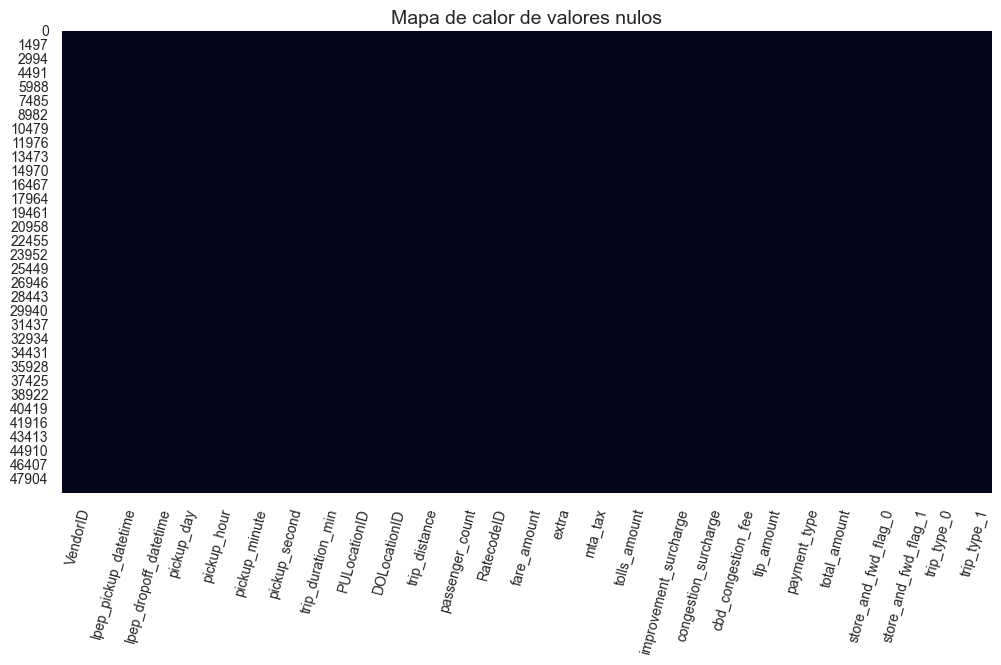

In [63]:
# Mapa de calor de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df_prep_knn.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
ax = plt.gca()
ax.tick_params(axis='x', rotation=75)

# Feature Engineering

### 3.8.1 Características Temporales (Feature Engineering)

Esta sección crea variables derivadas del timestamp de pickup para capturar patrones temporales relevantes para la predicción. Las características temporales son cruciales en el análisis de transporte urbano ya que los patrones de demanda, tráfico y tarifas varían significativamente según el momento del día y día de la semana.

Variables temporales generadas:
1. pickup_day_of_week: Día de la semana (0=lunes, 6=domingo)
2. pickup_is_weekend: Variable binaria para fines de semana
3. pickup_time_of_day_Ord: Segmentación ordinal del día (0=Noche, 4=Madrugada)
4. is_peak_hour: Identificación de horas pico de tráfico (7-9 AM, 4-7 PM)

In [64]:
df_prep = df_prep_knn.copy()

In [65]:
# Create pickup_date column from lpep_pickup_datetime if not already present
if 'pickup_date' not in df_prep.columns:
	df_prep['pickup_date'] = df_prep['lpep_pickup_datetime'].dt.date

# Extraer el día de la semana usando los datos disponibles (only if not already present)
if 'pickup_day_of_week' not in df_prep.columns:
	df_prep['pickup_day_of_week'] = df_prep['lpep_pickup_datetime'].dt.dayofweek

# Extraer día de la semana (método 1 - usando >= 5) (only if not already present)
if 'pickup_week' not in df_prep.columns:
	df_prep['pickup_week'] = df_prep['pickup_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Es fin de semana si es sábado (5) o domingo (6) (método 
if 'pickup_is_weekend' not in df_prep.columns:
	df_prep['pickup_is_weekend'] = df_prep['pickup_day_of_week'].isin([5, 6]).astype(int)

# Categorizar el día en Mañana, Tarde, Noche (ORDINAL)
df_prep['pickup_time_of_day'] = pd.cut(
	df_prep['pickup_hour'],
	bins=[0, 5, 12, 17, 21, 24],
	labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night'],
	right=False,
	ordered=True  # Cambiar a True para crear variable ordinal
)

# Crear mapeo ordinal para pickup_time_of_day (INMEDIATAMENTE después de crearla)
time_day_dic = {
    'Night' : 0, 
    'Morning' : 1, 
    'Afternoon' : 2, 
    'Evening' : 3, 
    'Late Night' : 4
}
# Aplicar el mapeo ordinal y convertir a tipo numérico
df_prep['pickup_time_of_day_Ord'] = df_prep['pickup_time_of_day'].map(time_day_dic).astype('int32')

# Drop pickup_time_of_day
try:
    df_prep = df_prep.drop(columns=['pickup_time_of_day'])
    print("Columna 'pickup_time_of_day' eliminada.")
except KeyError:
    print("Columna 'pickup_time_of_day' no existe, continuando...")

# hora Punta 
df_prep['is_peak_hour'] = df_prep['pickup_hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0)

Columna 'pickup_time_of_day' eliminada.


**Interpretación de resultados:**
La codificación ordinal del tiempo del día preserva la relación natural entre períodos temporales, mientras que las variables binarias para weekend y horas pico permiten a los modelos identificar patrones específicos de demanda. Estas variables son fundamentales para predecir tanto tarifas como duración de viajes en el contexto del transporte urbano de NYC.

### 3.8.2 Características del Viaje (Feature Engineering)

Esta sección genera variables derivadas que capturan la eficiencia, rentabilidad y características económicas de cada viaje. Estas métricas proporcionan insights valiosos sobre el comportamiento del servicio de taxi y permiten a los modelos capturar relaciones complejas entre variables.

Variables de eficiencia y económicas generadas:
1. average_speed_mph: Velocidad promedio del viaje en millas por hora
2. cost_per_mile_total: Costo total por milla recorrida
3. cost_per_minute_total: Costo total por minuto de viaje
4. tip_percentage_fare: Porcentaje de propina sobre la tarifa base
5. tolls_to_fare_ratio: Ratio de peajes respecto a la tarifa
6. surcharges_total: Suma total de todos los recargos aplicados
7. surcharges_to_total_ratio: Proporción de recargos en el total del viaje

In [66]:
#Calcular promedio de velocidad del viaje (millas por hora)
df_prep['average_speed_mph'] = np.where(
    df_prep['trip_duration_min'] > 0,
    (df_prep['trip_distance'] / (df_prep['trip_duration_min'] / 60)).round(2),
    0
)

#Costo por milla: Calcular total_amount / trip_distance o fare_amount / trip_distance. (¡Ojo con divisiones por cero!).
df_prep['cost_per_mile_total'] = np.where(
    df_prep['trip_distance'] > 0,
    (df_prep['total_amount'] / df_prep['trip_distance']).round(2),
    0
)

#Costo por minuto: Calcular total_amount / trip_duration_min o fare_amount / trip_duration_min. (¡Ojo con divisiones por cero!).
df_prep['cost_per_minute_total'] = np.where(
    df_prep['trip_duration_min'] > 0,
    (df_prep['total_amount'] / df_prep['trip_duration_min']).round(2),
    0
)

#Porcentaje de propina: Calcular (tip_amount / fare_amount) * 100 o (tip_amount / total_amount) * 100. (Manejar casos donde fare_amount o total_amount sean cero).
df_prep['tip_percentage_fare'] = np.where(
    df_prep['fare_amount'] > 0,
    (df_prep['tip_amount'] / df_prep['fare_amount'] * 100).round(2),
    0
)

#Ratio de peajes sobre tarifa: tolls_amount / fare_amount.
df_prep['tolls_to_fare_ratio'] = np.where(
    df_prep['fare_amount'] > 0,
    (df_prep['tolls_amount'] / df_prep['fare_amount']).round(2),
    0
)

#Suma de recargos: extra + mta_tax + improvement_surcharge + congestion_surcharge + cbd_congestion_fee.
df_prep['surcharges_total'] = (df_prep['extra'] + df_prep['mta_tax'] + df_prep['improvement_surcharge'] + df_prep['congestion_surcharge'] + df_prep['cbd_congestion_fee']).round(2)

#Ratio de recargos sobre total: Suma de recargos / total_amount.
df_prep['surcharges_to_total_ratio'] = np.where(
    df_prep['total_amount'] > 0,
    (df_prep['surcharges_total'] / df_prep['total_amount']).round(2),
    0
)

**Interpretación de resultados:**
 Estas variables capturan aspectos de eficiencia operacional (velocidad, costo por unidad) y comportamiento económico (propinas, recargos) que son cruciales para entender los patrones de pricing en el servicio de taxi. La inclusión de ratios y porcentajes normaliza las métricas y las hace más robustas ante variaciones de escala.

## 3.9 Organización por Dominio Semántico

Esta sección reorganiza las variables del dataset agrupándolas por dominios semánticos o temáticos. Esta organización facilita el análisis, la interpretación de resultados y la selección de características para modelos específicos, permitiendo una comprensión más clara de las relaciones entre variables.

Dominios definidos:
1. temporal_features: Variables relacionadas con tiempo y patrones temporales
2. metadata: Información del sistema y configuración del viaje  
3. trip_characteristics: Características físicas y operacionales del viaje
4. fare_breakdown: Descomposición detallada de la tarifa
5. tip_metrics: Métricas relacionadas con propinas
6. efficiency_ratios: Ratios de eficiencia y costo
7. total_amounts: Variable target principal

In [67]:
# Agrupación por dominio semántico
feature_domains = {
    'temporal_features': [
        'pickup_day', 'pickup_day_of_week',
        'pickup_is_weekend', 'pickup_hour',
        'pickup_time_of_day_Ord', 'is_peak_hour'
    ],
    'metadata': [
        'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 
        'payment_type','store_and_fwd_flag_0',
        'store_and_fwd_flag_1','trip_type_0','trip_type_1'
    ],

    'trip_characteristics': [
        'trip_distance', 'passenger_count', 'trip_duration_min', 'average_speed_mph'
    ],
    'fare_breakdown': [
        'fare_amount', 'extra', 'mta_tax', 'tolls_amount',
        'improvement_surcharge', 'congestion_surcharge', 'cbd_congestion_fee',
        'surcharges_total'
    ],
    'tip_metrics': [
        'tip_amount', 'tip_percentage_fare'
    ],
    'efficiency_ratios': [
        'cost_per_mile_total', 'cost_per_minute_total',
        'tolls_to_fare_ratio', 'surcharges_to_total_ratio'
    ],
    'total_amounts': [
        'total_amount'
    ]
}

# Crear lista ordenada desde los grupos
ordered_columns = []
for domain in feature_domains.values():
    ordered_columns.extend(domain)

df_final = df_prep[ordered_columns]

**Interpretación de resultados:**
 Esta estructura permite entender mejor las relaciones entre variables similares y simplifica la selección de características para modelado. La organización por dominios también facilita el análisis de importancia de características por categorías temáticas, lo que será valioso para la interpretación de resultados en las fases posteriores del proyecto.

## 3.10 Normalización de Datos (MinMaxScaler)

Esta sección aplica normalización MinMax a las variables numéricas para escalar todos los valores al rango [0,1]. Este proceso es esencial para algoritmos de machine learning sensibles a la escala de las variables, como KNN, SVM y redes neuronales.

Proceso de normalización para predicción de total_amount:
1. Identificación de variables numéricas continuas (excluyendo binarias)
2. Exclusión de la variable objetivo (total_amount) del escalado
3. Aplicación de MinMaxScaler a variables seleccionadas
4. Preservación de variables categóricas y binarias sin modificación

In [68]:
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Asumiendo que 'df_final' es tu DataFrame listo antes del escalado
df_minmax = df_final.copy() # Trabaja sobre una copia

# 1. Definir las columnas numéricas a escalar ---
# Combina las listas de feature_domains que contienen variables continuas o discretas
features_to_scale_lists = [
    feature_domains.get('temporal_features', []),      # ← Variables temporales
    feature_domains.get('metadata', []),             # ← EXCLUIR: Son IDs y categorías
    feature_domains.get('trip_characteristics', []),   # ← Características del viaje  
    feature_domains.get('fare_breakdown', []),         # ← Desglose de tarifas
    feature_domains.get('tip_metrics', []),            # ← Métricas de propinas
    feature_domains.get('efficiency_ratios', []),      # ← Ratios de eficiencia
    feature_domains.get('total_amounts', [])         # ← EXCLUIR: Variable objetivo
]

# Aplanar la lista de listas
features_to_scale = [item for sublist in features_to_scale_lists for item in sublist]

# Filtrar para asegurarse de que solo sean numéricas y existan en el DataFrame
target_variable = 'total_amount'  # Definir la variable objetivo
cols_numericas_total = []

for col in features_to_scale:
    if col in df_minmax.columns and pd.api.types.is_numeric_dtype(df_minmax[col]):
        unique_values = df_minmax[col].nunique()
        # Excluir variables binarias (0/1), pocas categorías Y la variable objetivo
        if unique_values > 2 and col != target_variable: 
            cols_numericas_total.append(col)
        else:
            if col == target_variable:
                print(f"Excluir: {col:<25} (variable objetivo)")
            else:
                print(f"Excluir: {col:<25} (binaria/pocas categorías: {unique_values} valores)")
    else:
        print(f"Excluir: {col:<25} (no existe o no es numérica)")
# 2. Aplicar MinMaxScaler ---
print(f"\nEscalado MinMaxScaler (Normalización [0, 1])")
print(f"Variable objetivo: '{target_variable}' - NO SE ESCALA")
print(f"Variables a escalar: {len(cols_numericas_total)}")
print("---")

if not cols_numericas_total:
    print("No se encontraron columnas numéricas adecuadas para escalar.")
else:
    # Crear el objeto MinMaxScaler
    scaler_minmax = MinMaxScaler()
    
    # Aplicando al DataFrame completo:
    df_minmax[cols_numericas_total] = scaler_minmax.fit_transform(df_minmax[cols_numericas_total])
    df_total= df_minmax

Excluir: pickup_is_weekend         (binaria/pocas categorías: 2 valores)
Excluir: is_peak_hour              (binaria/pocas categorías: 2 valores)
Excluir: store_and_fwd_flag_0      (binaria/pocas categorías: 2 valores)
Excluir: store_and_fwd_flag_1      (binaria/pocas categorías: 2 valores)
Excluir: trip_type_0               (binaria/pocas categorías: 2 valores)
Excluir: trip_type_1               (binaria/pocas categorías: 2 valores)
Excluir: improvement_surcharge     (binaria/pocas categorías: 2 valores)
Excluir: cbd_congestion_fee        (binaria/pocas categorías: 2 valores)
Excluir: total_amount              (variable objetivo)

Escalado MinMaxScaler (Normalización [0, 1])
Variable objetivo: 'total_amount' - NO SE ESCALA
Variables a escalar: 25
---


**Interpretación de resultados:**
La normalización MinMax se ha aplicado exitosamente a las variables numéricas continuas para la predicción de total_amount. El proceso ha escalado las características al rango [0,1] mientras preserva las relaciones proporcionales entre valores. Las variables binarias y categóricas se mantuvieron sin modificar, y la variable objetivo total_amount se preservó en su escala original para facilitar la interpretación de predicciones.

### 3.10.2 Normalización para Predicción de Trip Duration

Esta celda aplica el mismo proceso de normalización MinMax pero orientado a la predicción de trip_duration_min como variable objetivo. La estrategia es idéntica pero adapta la exclusión de variables objetivo para este segundo modelo predictivo.

Diferencias clave en esta normalización:
1. Variable objetivo: trip_duration_min (excluida del escalado)
2. Mismas variables numéricas escaladas al rango [0,1]
3. Generación de dataset específico para modelado de duración de viajes

In [69]:
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Asumiendo que 'df_final' es tu DataFrame listo antes del escalado
df_minmax = df_final.copy() # Trabaja sobre una copia

# 1. Definir las columnas numéricas a escalar ---
# Combina las listas de feature_domains que contienen variables continuas o discretas
features_to_scale_lists = [
    feature_domains.get('temporal_features', []),      # ← Variables temporales
    feature_domains.get('metadata', []),             # ← EXCLUIR: Son IDs y categorías
    feature_domains.get('trip_characteristics', []),   # ← Características del viaje  
    feature_domains.get('fare_breakdown', []),         # ← Desglose de tarifas
    feature_domains.get('tip_metrics', []),            # ← Métricas de propinas
    feature_domains.get('efficiency_ratios', []),      # ← Ratios de eficiencia
    feature_domains.get('total_amounts', [])         # ← EXCLUIR: Variable objetivo
]

# Aplanar la lista de listas
features_to_scale = [item for sublist in features_to_scale_lists for item in sublist]

# Filtrar para asegurarse de que solo sean numéricas y existan en el DataFrame
target_variable = 'trip_duration_min'  # Definir la variable objetivo
cols_numericas_trip = []

for col in features_to_scale:
    if col in df_minmax.columns and pd.api.types.is_numeric_dtype(df_minmax[col]):
        unique_values = df_minmax[col].nunique()
        # Excluir variables binarias (0/1), pocas categorías Y la variable objetivo
        if unique_values > 2 and col != target_variable: 
            cols_numericas_trip.append(col)
        else:
            if col == target_variable:
                print(f"Excluir: {col:<25} (variable objetivo)")
            else:
                print(f"Excluir: {col:<25} (binaria/pocas categorías: {unique_values} valores)")
    else:
        print(f"Excluir: {col:<25} (no existe o no es numérica)")
# 2. Aplicar MinMaxScaler ---
print(f"\nEscalado MinMaxScaler (Normalización [0, 1])")
print(f"Variable objetivo: '{target_variable}' - NO SE ESCALA")
print(f"Variables a escalar: {len(cols_numericas_trip)}")
print("---")

if not cols_numericas_trip:
    print("No se encontraron columnas numéricas adecuadas para escalar.")
else:
    # Crear el objeto MinMaxScaler
    scaler_minmax = MinMaxScaler()
    
    # Aplicando al DataFrame completo:
    df_minmax[cols_numericas_trip] = scaler_minmax.fit_transform(df_minmax[cols_numericas_trip])
    df_trip = df_minmax

Excluir: pickup_is_weekend         (binaria/pocas categorías: 2 valores)
Excluir: is_peak_hour              (binaria/pocas categorías: 2 valores)
Excluir: store_and_fwd_flag_0      (binaria/pocas categorías: 2 valores)
Excluir: store_and_fwd_flag_1      (binaria/pocas categorías: 2 valores)
Excluir: trip_type_0               (binaria/pocas categorías: 2 valores)
Excluir: trip_type_1               (binaria/pocas categorías: 2 valores)
Excluir: trip_duration_min         (variable objetivo)
Excluir: improvement_surcharge     (binaria/pocas categorías: 2 valores)
Excluir: cbd_congestion_fee        (binaria/pocas categorías: 2 valores)

Escalado MinMaxScaler (Normalización [0, 1])
Variable objetivo: 'trip_duration_min' - NO SE ESCALA
Variables a escalar: 25
---


**Interpretación de resultados:**
Se ha completado la normalización del dataset para predicción de duración de viajes (trip_duration_min). Este enfoque dual permite crear dos datasets optimizados para diferentes objetivos predictivos: uno para tarifas y otro para duración. Ambos datasets mantienen las mismas características normalizadas pero preservan diferentes variables objetivo en su escala original, facilitando el entrenamiento y evaluación de modelos especializados.

In [70]:
df_total = df_total.copy()
df_trip = df_trip.copy()


## 3.11 Análisis de Correlación entre Variables

Esta sección genera una matriz de correlación completa para identificar relaciones lineales entre variables numéricas. El análisis de correlación es fundamental para entender las interdependencias entre características y detectar posibles problemas de multicolinealidad que podrían afectar el rendimiento de los modelos.

Objetivos del análisis de correlación:
1. Identificar variables altamente correlacionadas (|r| > 0.8)
2. Detectar relaciones no evidentes entre características
3. Informar decisiones sobre selección de características
4. Visualizar patrones de asociación en el dataset normalizado

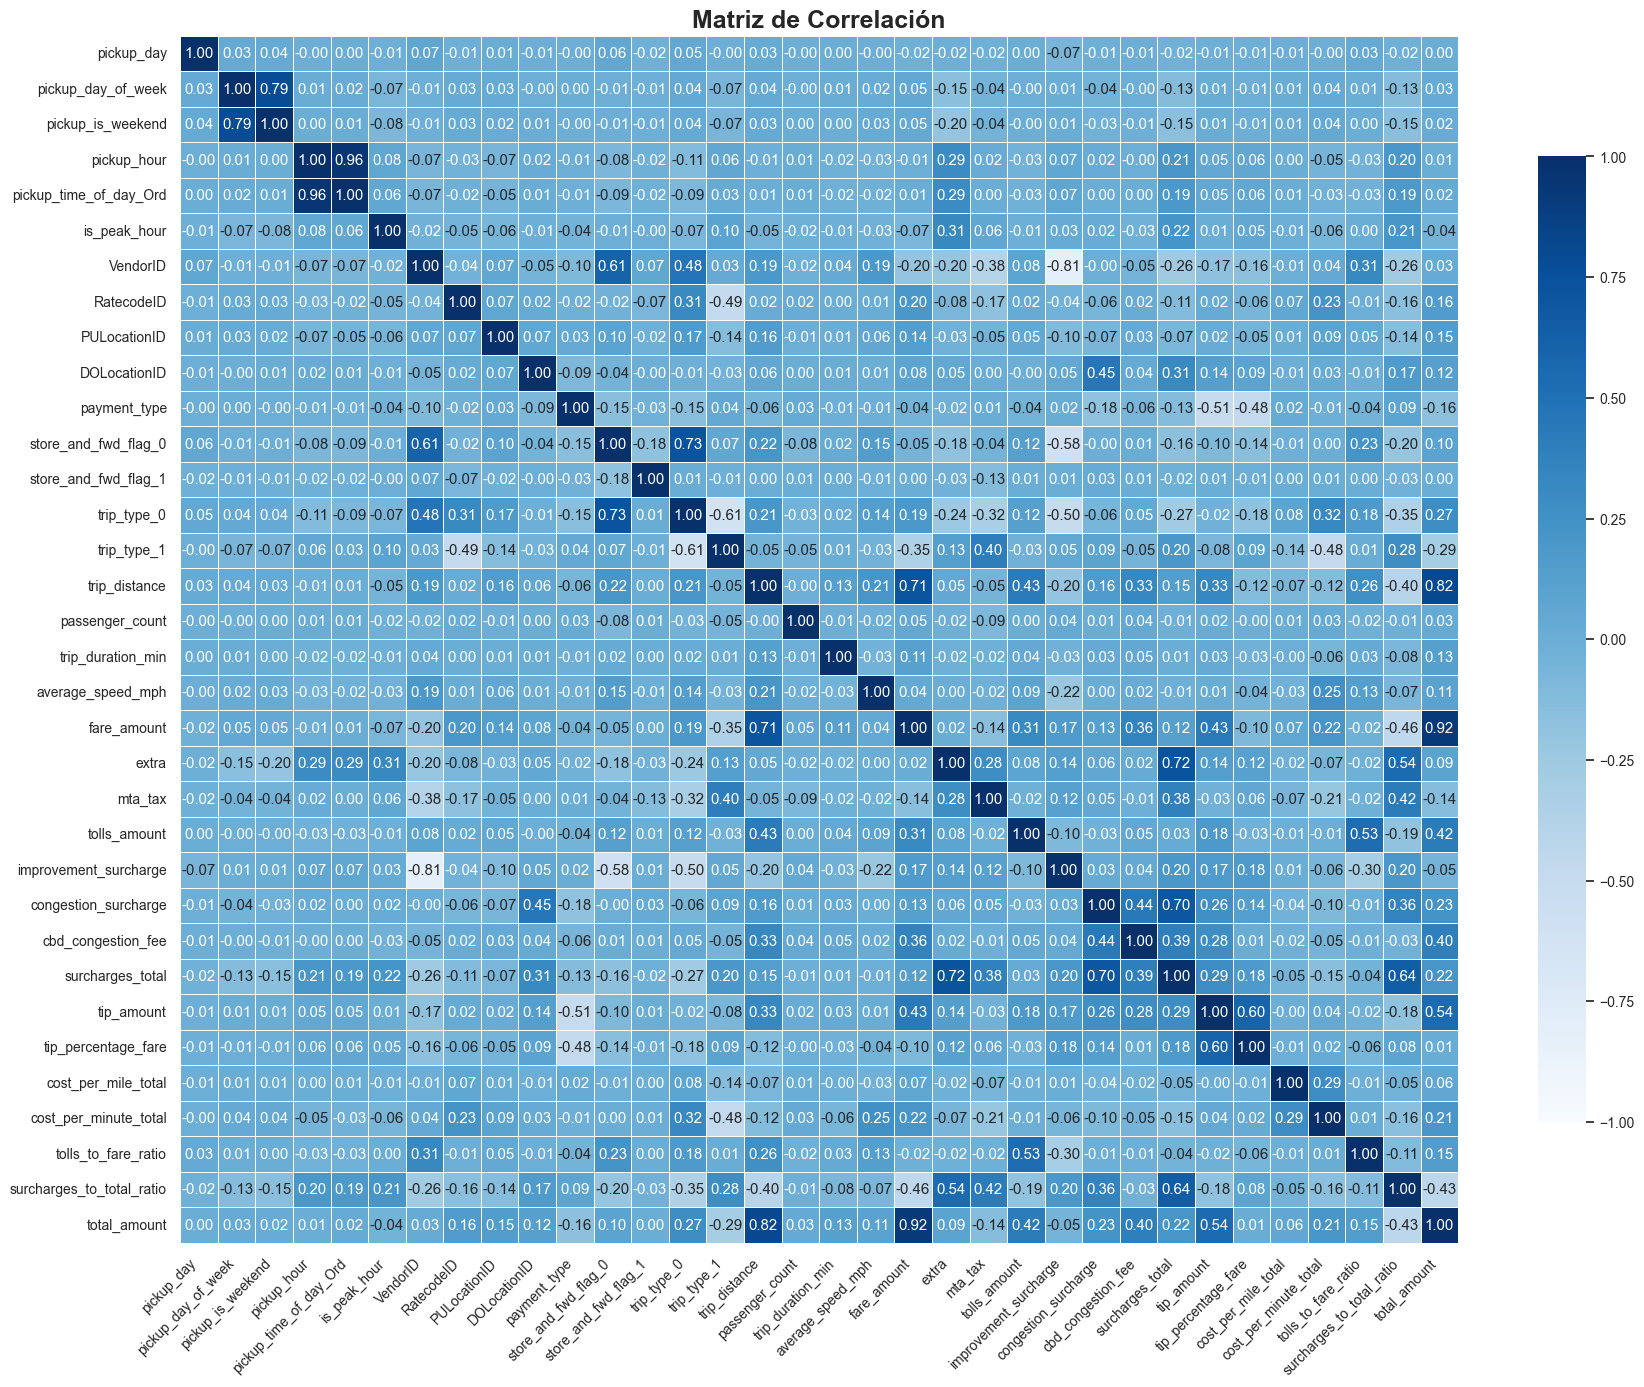

In [71]:
# Seleccionar columnas numéricas y rellenar valores faltantes
numeric_cols_for_corr = df_total.select_dtypes(include=[np.number]).columns
df_prep_for_corr = df_total[numeric_cols_for_corr].copy()
# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

plt.figure(figsize=(18, 14))
#sns.heatmap(corr, annot=True,cmap='Blues',fmt=".3f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

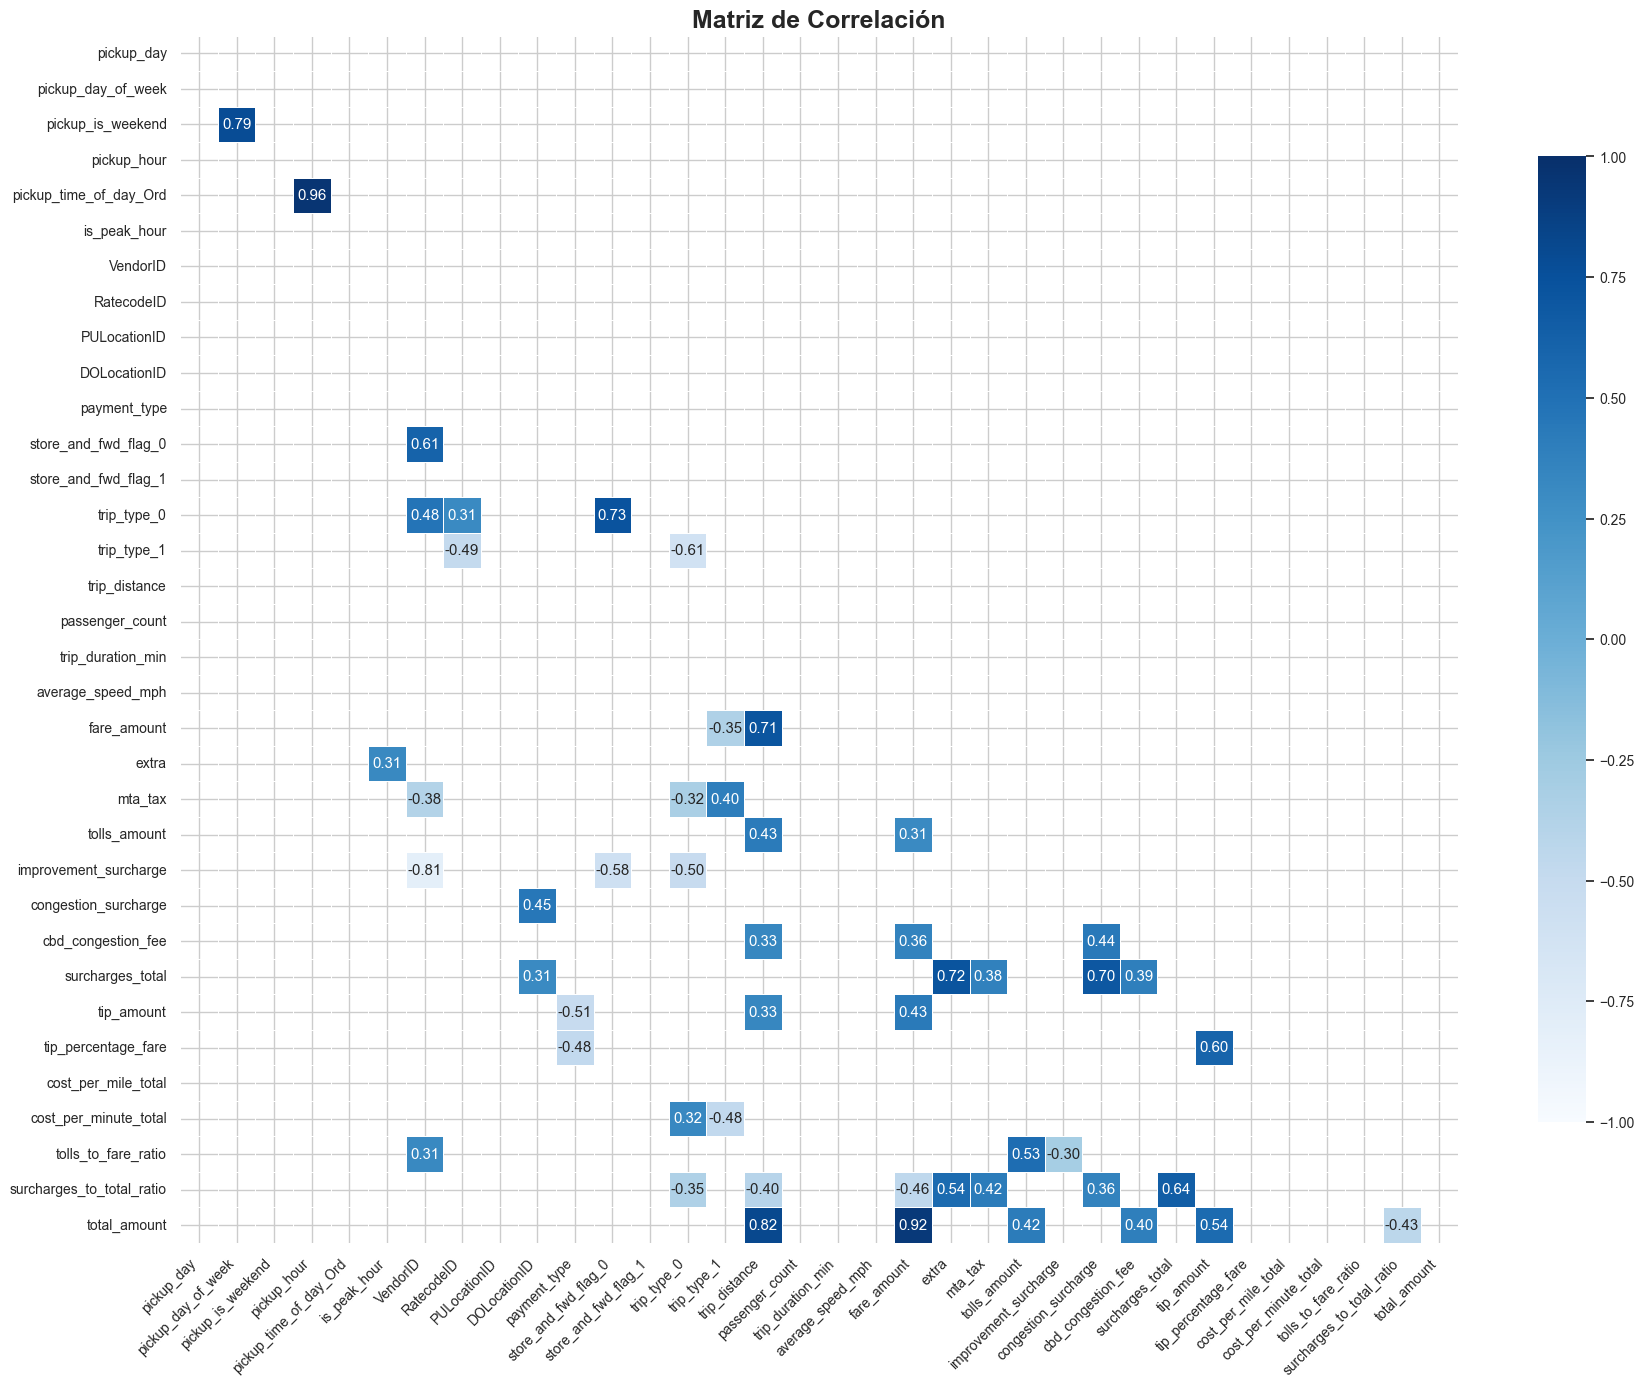

In [72]:
# Visualiza solo un lado del Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool)) | (np.abs(corr) < 0.3)
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación de resultados:**
La matriz de correlación revela las relaciones lineales significativas entre las variables del dataset. Las correlaciones más fuertes identificadas proporcionan insights valiosos sobre las interdependencias entre características. Las correlaciones altas entre variables relacionadas (como componentes de tarifa) son esperadas, mientras que correlaciones moderadas con las variables objetivo indican potencial predictivo. Esta información guiará la selección de características y detectará posibles problemas de multicolinealidad en el modelado.

In [73]:
# Asumiendo que df_final es tu DataFrame inicial
df_prep = df_total.copy()
target_col = 'total_amount' # Assuming this is your target

print("\nLimpieza de Columnas: Varianza Cero + Baja Correlación")
print("---")

# 1. Varianza Cero
zero_var_cols = [col for col in df_prep.select_dtypes(include=[np.number]).columns
                 if col in corr.columns and df_prep[col].var() < 1e-10] 
if zero_var_cols:
    print(f"- Se encontraron {len(zero_var_cols)} columnas con varianza cero:")
    for col in zero_var_cols:
        print(f"  ✗ {col}")
    df_prep = df_prep.drop(columns=zero_var_cols)

# 2. Baja Correlación (Excluyendo trip_duration_min y pickup_time_of_day_Ord)
df_prep_lows = df_prep.copy() # Trabaja sobre una copia para esta parte
low_corr_cols = [] # Inicializa la lista

if target_col in df_prep.columns:
    # Seleccionar solo columnas numéricas existentes para correlación
    numeric_cols = df_prep.select_dtypes(include=np.number).columns
    if target_col in numeric_cols: # Asegúrate que el target es numérico
        corrs = df_prep[numeric_cols].corr()[target_col].abs()
        
        # Identificar columnas con baja correlación, EXCLUYENDO explícitamente variables importantes
        low_corr_cols = [col for col in corrs[(corrs < 0.2) & (corrs.index != target_col)].index
                         if col != 'total_amount']

        if low_corr_cols:
            print(f"Se encontraron {len(low_corr_cols)} columnas con baja correlación (<0.2):")
            for col in low_corr_cols:
                corr_value = corrs[col]
                print(f"  ✗ {col:<30} (correlación: {corr_value:.3f})")
            # Aplicar la eliminación en la copia df_prep_lows
            df_prep_lows = df_prep_lows.drop(columns=low_corr_cols).round(4)
        else:
            print("No se encontraron columnas con baja correlación para eliminar.")

print("\nDimensiones Finales")
print(f"DataFrame original ('df_prep'): {df_prep.shape[1]} columnas, {df_prep.shape[0]} filas (solo eliminada varianza cero)")
print(f"DataFrame filtrado ('df_prep_lows'): {df_prep_lows.shape[1]} columnas, {df_prep_lows.shape[0]} filas (eliminadas varianza cero y baja corr.)")
print("---")


Limpieza de Columnas: Varianza Cero + Baja Correlación
---
Se encontraron 22 columnas con baja correlación (<0.2):
  ✗ pickup_day                     (correlación: 0.003)
  ✗ pickup_day_of_week             (correlación: 0.030)
  ✗ pickup_is_weekend              (correlación: 0.019)
  ✗ pickup_hour                    (correlación: 0.007)
  ✗ pickup_time_of_day_Ord         (correlación: 0.025)
  ✗ is_peak_hour                   (correlación: 0.040)
  ✗ VendorID                       (correlación: 0.030)
  ✗ RatecodeID                     (correlación: 0.159)
  ✗ PULocationID                   (correlación: 0.151)
  ✗ DOLocationID                   (correlación: 0.122)
  ✗ payment_type                   (correlación: 0.159)
  ✗ store_and_fwd_flag_0           (correlación: 0.098)
  ✗ store_and_fwd_flag_1           (correlación: 0.004)
  ✗ passenger_count                (correlación: 0.032)
  ✗ trip_duration_min              (correlación: 0.127)
  ✗ average_speed_mph              (correlac

**Interpretación de resultados:**
El proceso de selección de características ha identificado y eliminado variables con baja capacidad predictiva para total_amount. Se mantuvieron dos versiones del dataset: una conservadora (solo eliminación de varianza cero) y otra optimizada (eliminación adicional de baja correlación). Esta estrategia dual permite comparar el rendimiento de modelos con diferentes niveles de selección de características, balanceando entre exhaustividad e información predictiva relevante.

## 3.12 Selección Final de Características

Esta sección implementa la limpieza final del dataset eliminando variables que no contribuyen al poder predictivo del modelo. Se aplican dos criterios de filtrado estadísticamente fundamentados para optimizar la calidad del dataset para modelado.

Criterios de eliminación aplicados:
1. Varianza cero: Variables sin variabilidad (constantes) que no aportan información
2. Baja correlación con target: Variables con correlación absoluta menor a 0.2 con total_amount
3. Preservación de variables críticas: Mantenimiento de variables conceptualmente importantes

In [74]:
df_total_lows = df_prep_lows.copy()

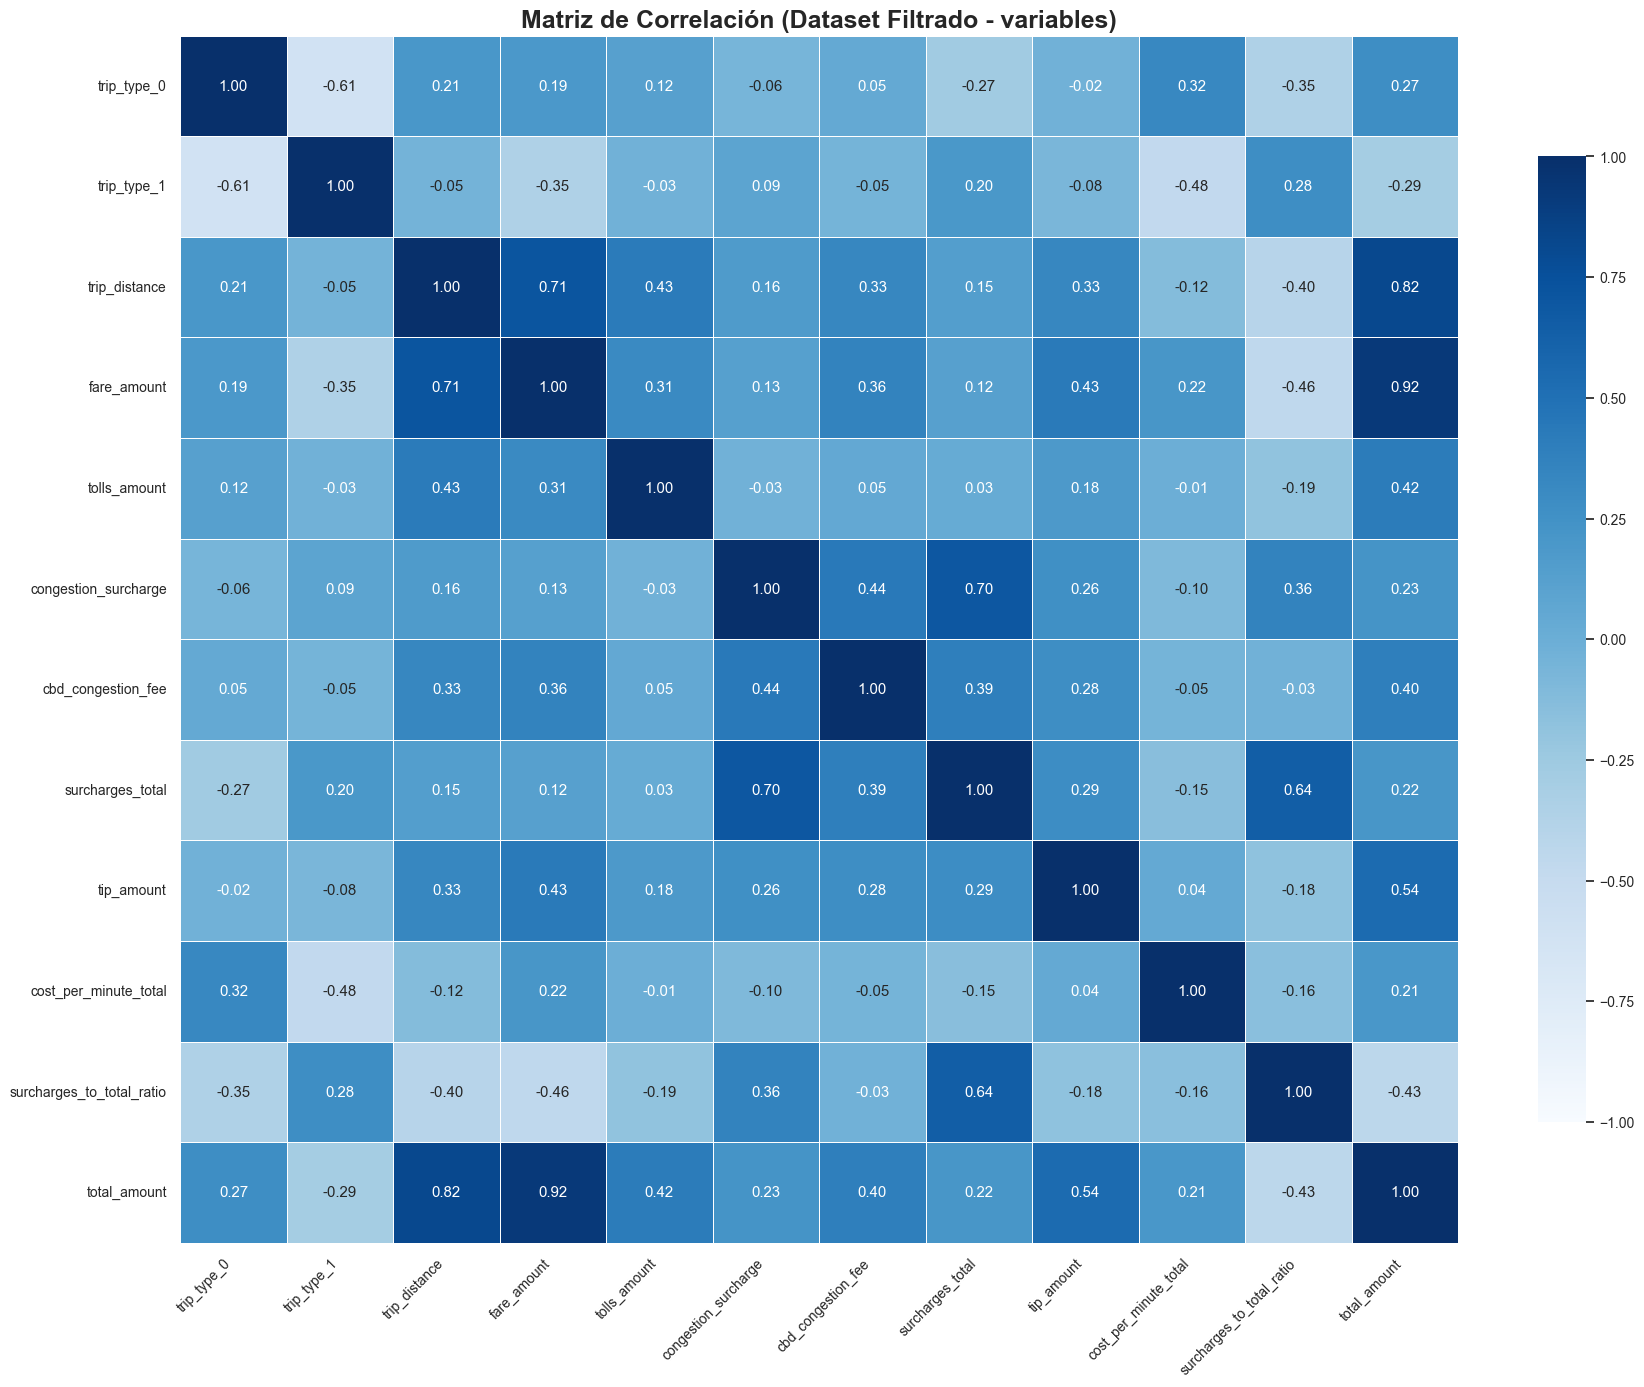

In [75]:
# Seleccionar columnas numéricas del DataFrame filtrado (df_total_lows)
numeric_cols_for_corr = df_total_lows.select_dtypes(include=[np.number]).columns
df_prep_for_corr = df_total_lows[numeric_cols_for_corr].copy()

# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

plt.figure(figsize=(18, 14))
#sns.heatmap(corr, annot=True,cmap='Blues',fmt=".3f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación (Dataset Filtrado - variables)", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

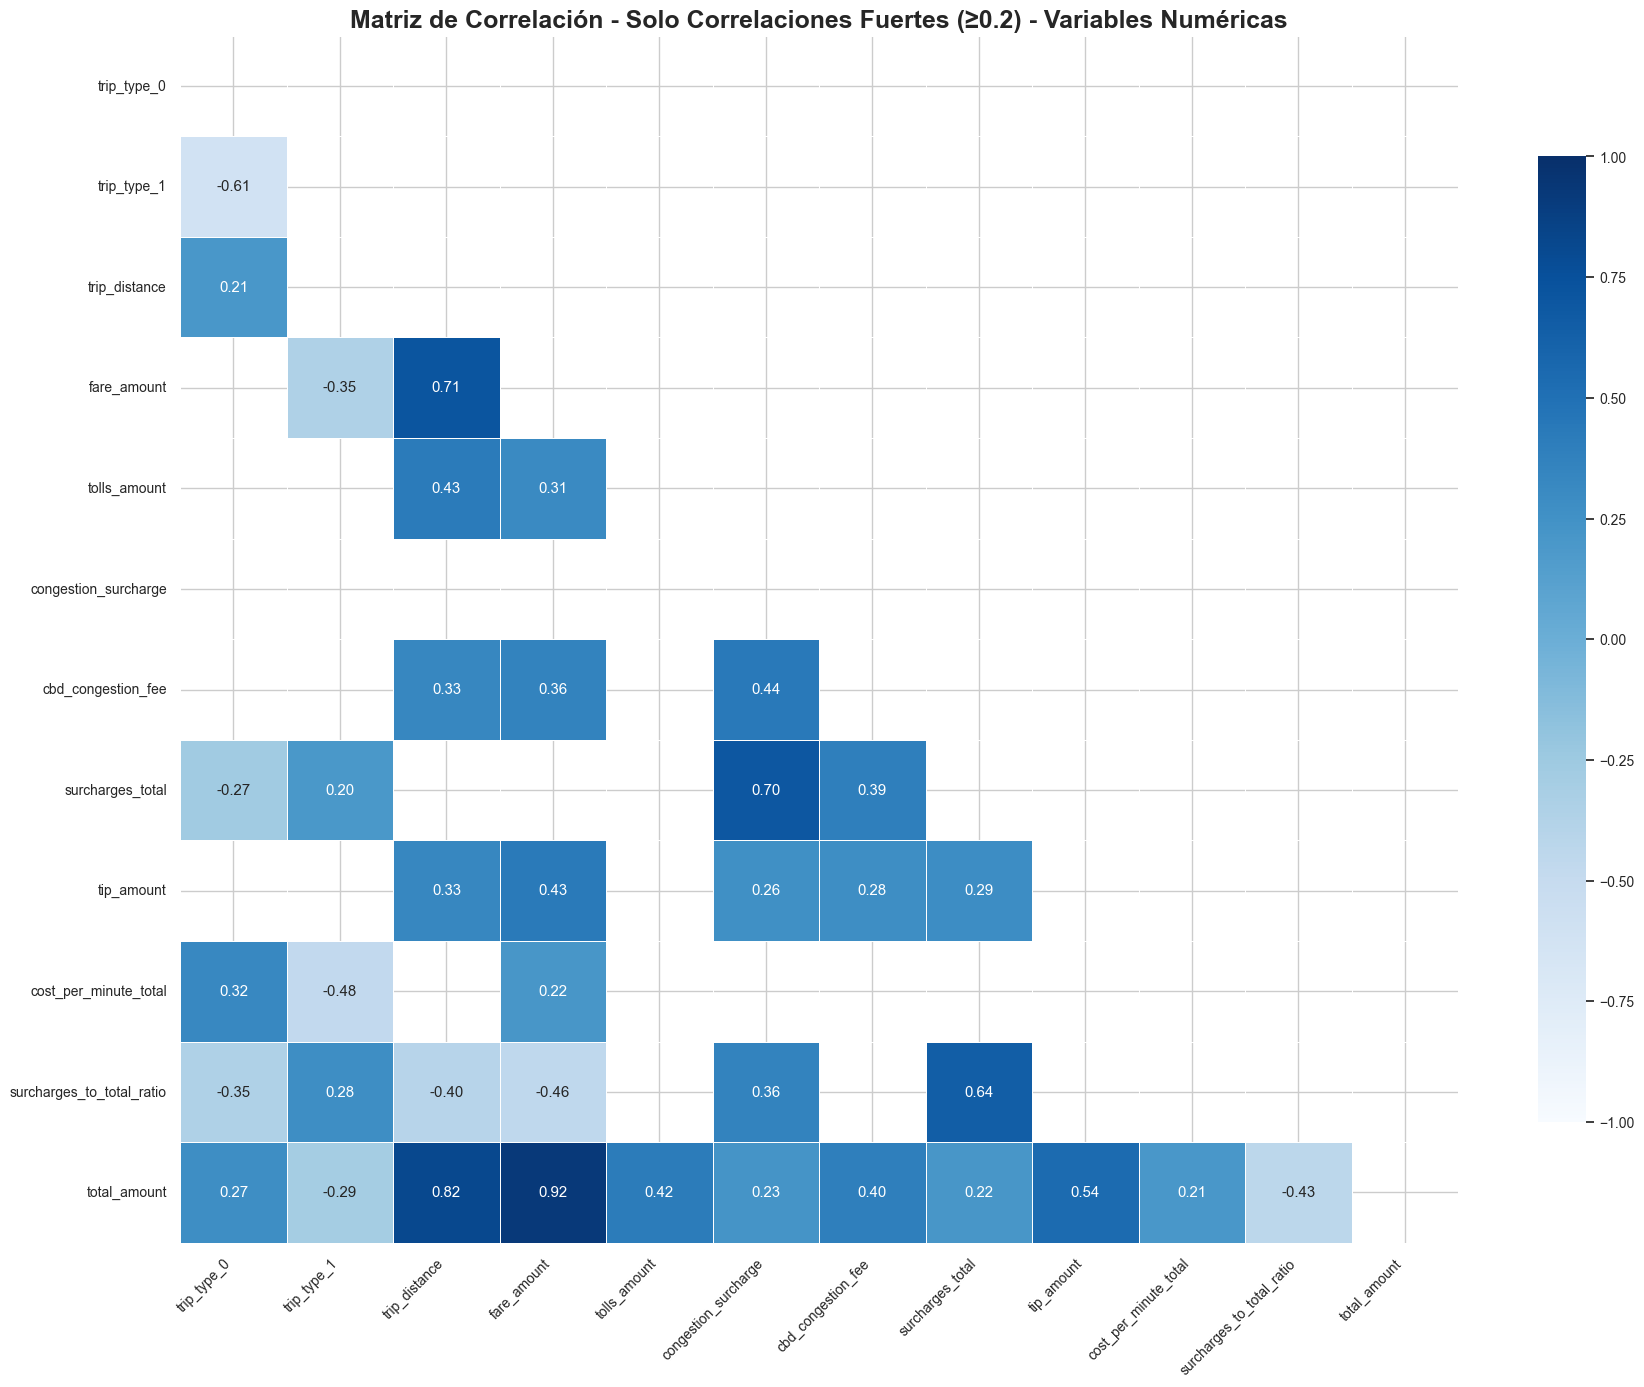

In [76]:
# Heatmap con máscara para correlaciones fuertes (≥0.2) - Dataset filtrado
mask = np.triu(np.ones_like(corr, dtype=bool)) | (np.abs(corr) < 0.2)
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f", mask=mask, 
            linewidths=.5, cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Solo Correlaciones Fuertes (≥0.2) - Variables Numéricas", 
          fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
# Define el nombre del archivo
datapreparation = 'preparation_total_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_prep en formato Parquet
try:
    df_total_lows.to_parquet(datapreparation, index=True) 
    print(f"DataFrame guardado exitosamente como '{datapreparation}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'preparation_total_green_tripdata_2025-06.parquet'


**Interpretación de resultados:**
El dataset para predicción de total_amount se ha exportado exitosamente como 'preparation_total_green_tripdata_2025-06.parquet'. Este archivo representa la culminación del proceso de preparación de datos y está listo para la fase de modelado. Contiene únicamente las características más relevantes, normalizadas y optimizadas para maximizar el rendimiento predictivo de modelos de machine learning enfocados en la predicción de tarifas de taxi.

### 3.12.1 Exportación del Dataset para Predicción de Total Amount

Esta celda exporta el dataset optimizado para la predicción de total_amount en formato Parquet. Este archivo contiene todas las transformaciones aplicadas: tratamiento de outliers, imputación, feature engineering, normalización y selección de características.

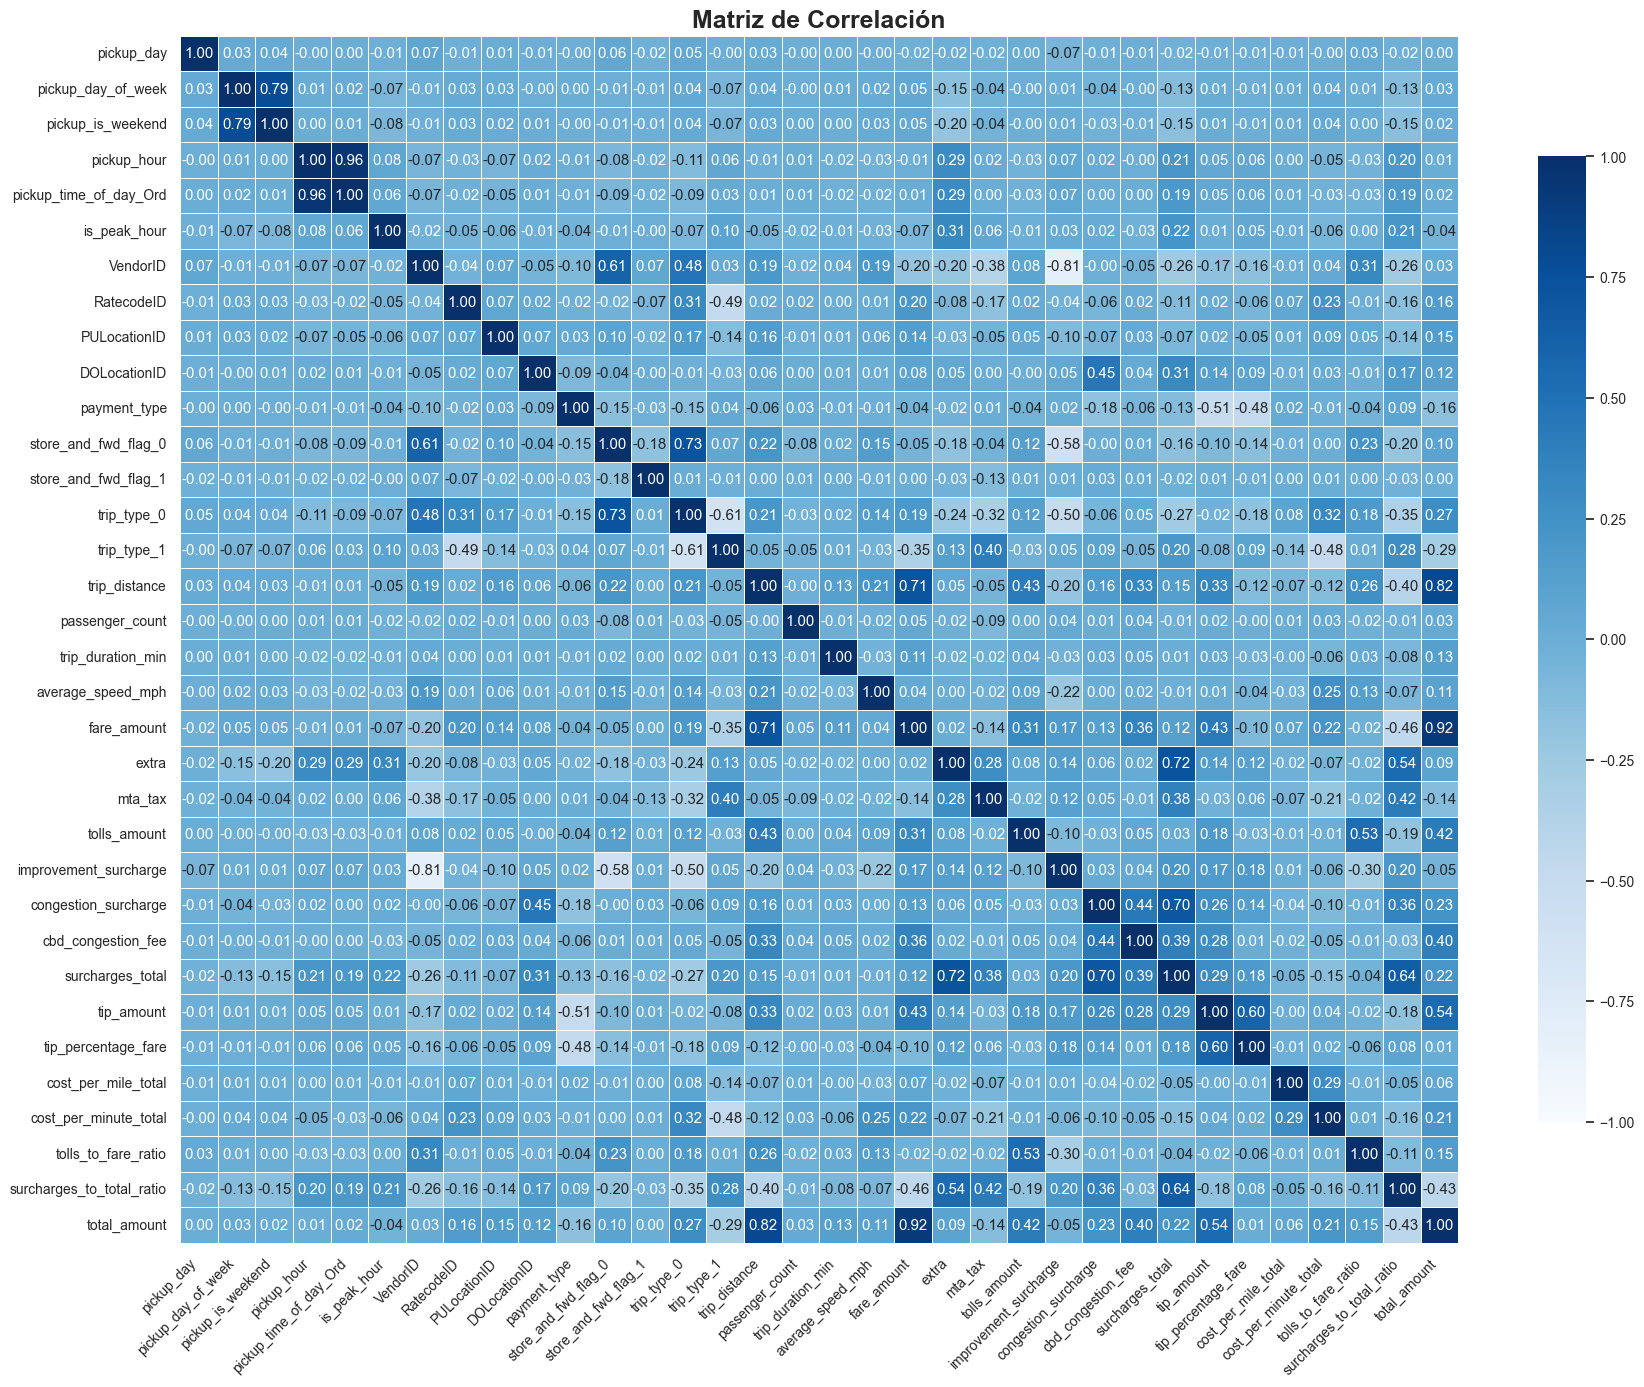

In [78]:
# Seleccionar columnas numéricas y rellenar valores faltantes
numeric_cols_for_corr = df_trip.select_dtypes(include=[np.number]).columns
df_prep_for_corr = df_trip[numeric_cols_for_corr].copy()
# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

plt.figure(figsize=(18, 14))
#sns.heatmap(corr, annot=True,cmap='Blues',fmt=".3f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

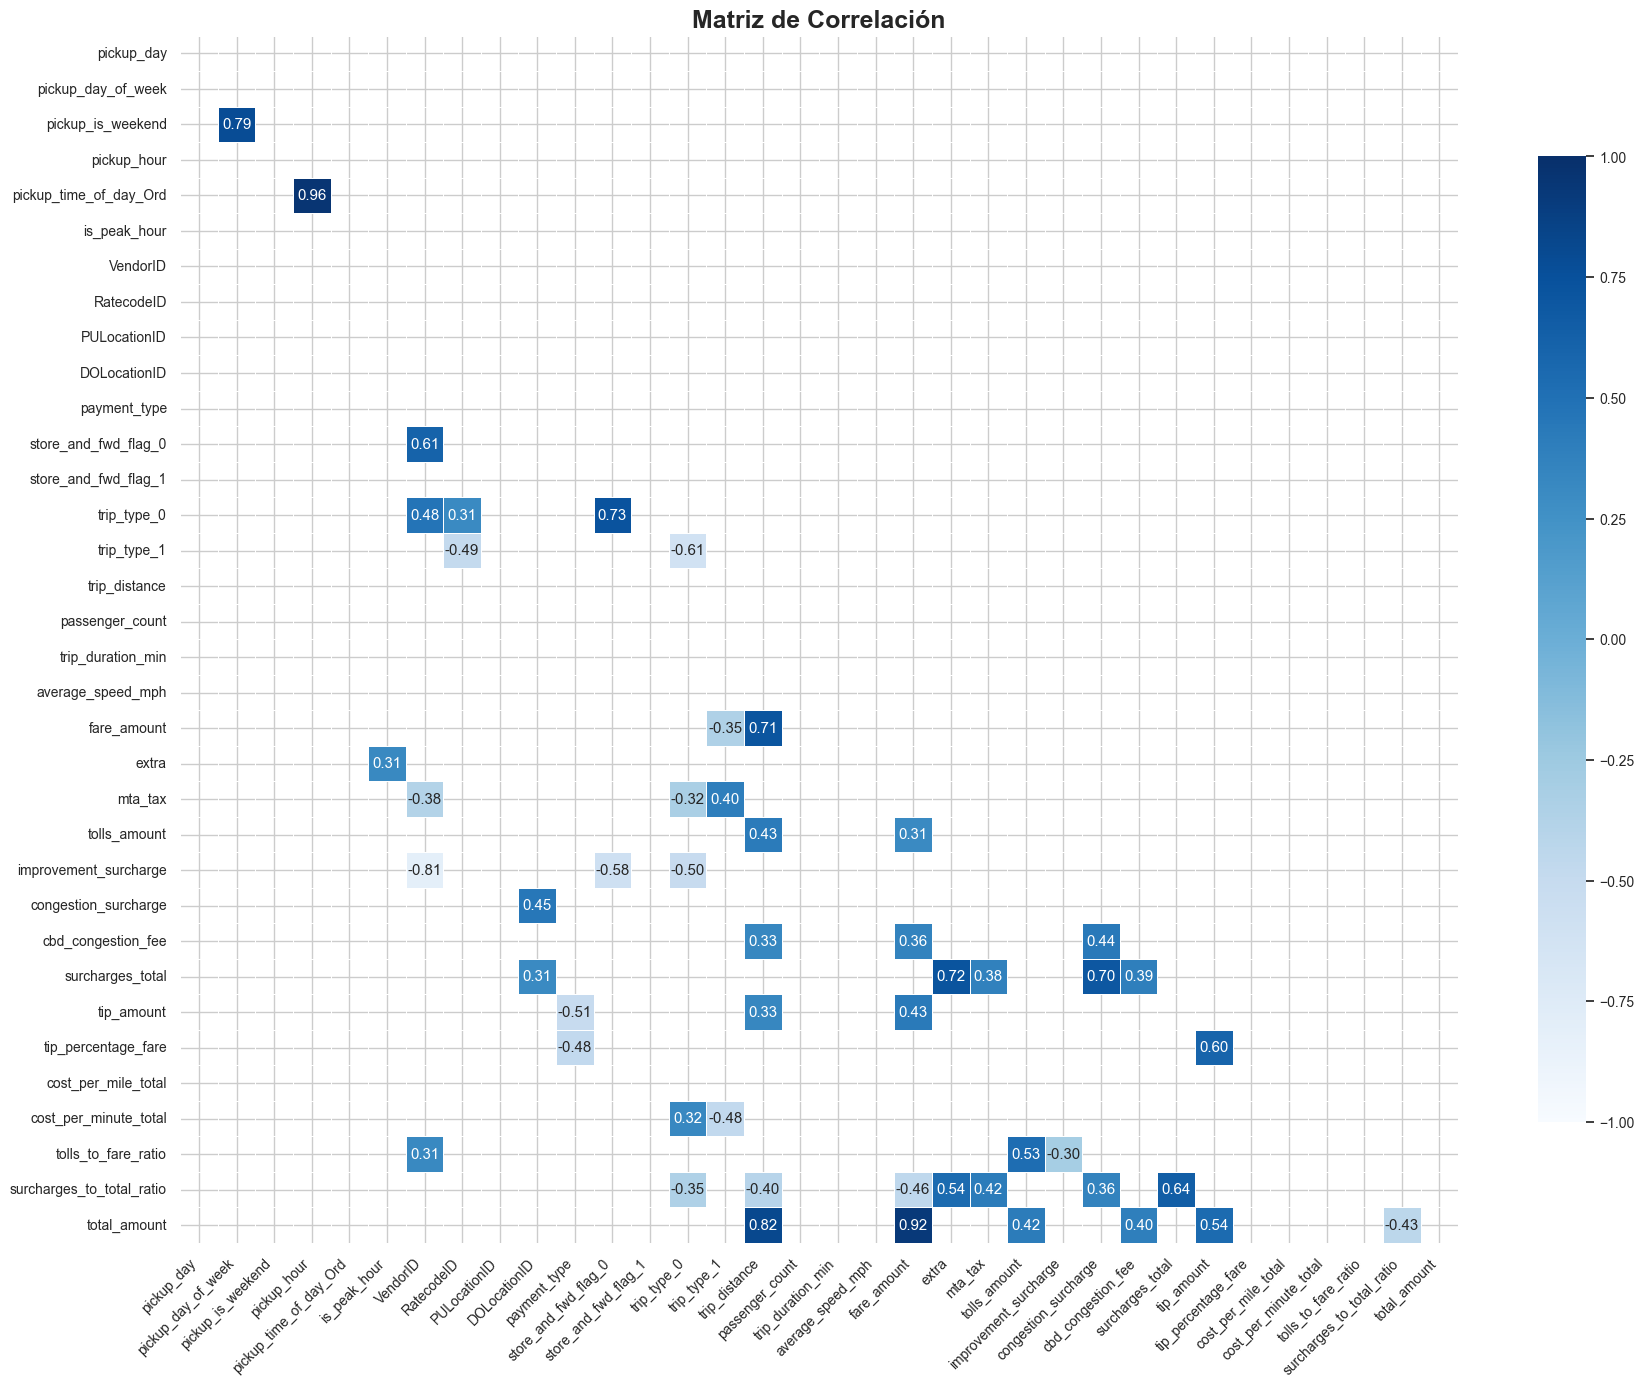

In [79]:
# Visualiza solo un lado del Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool)) | (np.abs(corr) < 0.3)
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.12.2 Selección de Características para Predicción de Trip Duration

Esta sección replica el proceso de selección de características pero orientado a la predicción de trip_duration_min como variable objetivo. Se aplican los mismos criterios estadísticos con umbral más estricto (correlación < 0.1) debido a la naturaleza específica de esta variable temporal.

Adaptaciones para trip duration:
1. Variable objetivo: trip_duration_min en lugar de total_amount
2. Umbral de correlación más estricto (0.1) para mayor selectividad
3. Preservación de variables temporales y operacionales relevantes para duración

In [80]:
# Asumiendo que df_final es tu DataFrame inicial
df_prep = df_trip.copy()
target_col = 'trip_duration_min' # Assuming this is your target

print("\nLimpieza de Columnas: Varianza Cero + Baja Correlación")
print("---")

# 1. Varianza Cero
zero_var_cols = [col for col in df_prep.select_dtypes(include=np.number).columns 
                 if col in corr.columns and df_prep[col].var() < 1e-10] 
if zero_var_cols:
    print(f"- Se encontraron {len(zero_var_cols)} columnas con varianza cero:")
    for col in zero_var_cols:
        print(f"  ✗ {col}")
    df_prep = df_prep.drop(columns=zero_var_cols)

# 2. Baja Correlación (Excluyendo trip_duration_min y pickup_time_of_day_Ord)
df_prep_lows = df_prep.copy() # Trabaja sobre una copia para esta parte
low_corr_cols = [] # Inicializa la lista

if target_col in df_prep.columns:
    # Seleccionar solo columnas numéricas existentes para correlación
    numeric_cols = df_prep.select_dtypes(include=np.number).columns
    if target_col in numeric_cols: # Asegúrate que el target es numérico
        corrs = df_prep[numeric_cols].corr()[target_col].abs()
        
        # Identificar columnas con baja correlación, EXCLUYENDO explícitamente variables importantes
        low_corr_cols = [col for col in corrs[(corrs < 0.1) & (corrs.index != target_col)].index 
                         if col != 'trip_duration_min'] 
        
        if low_corr_cols:
            print(f"Se encontraron {len(low_corr_cols)} columnas con baja correlación (<0.2):")
            for col in low_corr_cols:
                corr_value = corrs[col]
                print(f"  ✗ {col:<30} (correlación: {corr_value:.3f})")
            # Aplicar la eliminación en la copia df_prep_lows
            df_prep_lows = df_prep_lows.drop(columns=low_corr_cols).round(4)
        else:
            print("No se encontraron columnas con baja correlación para eliminar.")

print("\nDimensiones Finales")
print(f"DataFrame original ('df_prep'): {df_prep.shape[1]} columnas, {df_prep.shape[0]} filas (solo eliminada varianza cero)")
print(f"DataFrame filtrado ('df_prep_lows'): {df_prep_lows.shape[1]} columnas, {df_prep_lows.shape[0]} filas (eliminadas varianza cero y baja corr.)")
print("---")


Limpieza de Columnas: Varianza Cero + Baja Correlación
---
Se encontraron 30 columnas con baja correlación (<0.2):
  ✗ pickup_day                     (correlación: 0.004)
  ✗ pickup_day_of_week             (correlación: 0.008)
  ✗ pickup_is_weekend              (correlación: 0.004)
  ✗ pickup_hour                    (correlación: 0.017)
  ✗ pickup_time_of_day_Ord         (correlación: 0.018)
  ✗ is_peak_hour                   (correlación: 0.011)
  ✗ VendorID                       (correlación: 0.039)
  ✗ RatecodeID                     (correlación: 0.002)
  ✗ PULocationID                   (correlación: 0.007)
  ✗ DOLocationID                   (correlación: 0.009)
  ✗ payment_type                   (correlación: 0.009)
  ✗ store_and_fwd_flag_0           (correlación: 0.024)
  ✗ store_and_fwd_flag_1           (correlación: 0.004)
  ✗ trip_type_0                    (correlación: 0.017)
  ✗ trip_type_1                    (correlación: 0.005)
  ✗ passenger_count                (correlac

**Interpretación de resultados:**
La selección de características para predicción de trip_duration_min ha sido completada con criterios más estrictos que reflejan la complejidad de predecir duración temporal. El umbral de correlación reducido (0.1) asegura que solo las variables más predictivas permanezcan en el dataset. Esta estrategia selectiva es apropiada para trip_duration_min ya que factores temporales y operacionales específicos tienen mayor influencia que variables económicas.

In [81]:
df_trip_lows = df_prep_lows.copy()

### 3.12.3 Exportación del Dataset para Predicción de Trip Duration

Esta celda final exporta el dataset optimizado para la predicción de trip_duration_min. Este segundo dataset representa una versión especializada del pipeline de preparación, adaptada específicamente para modelado de duración temporal de viajes en taxis de NYC.

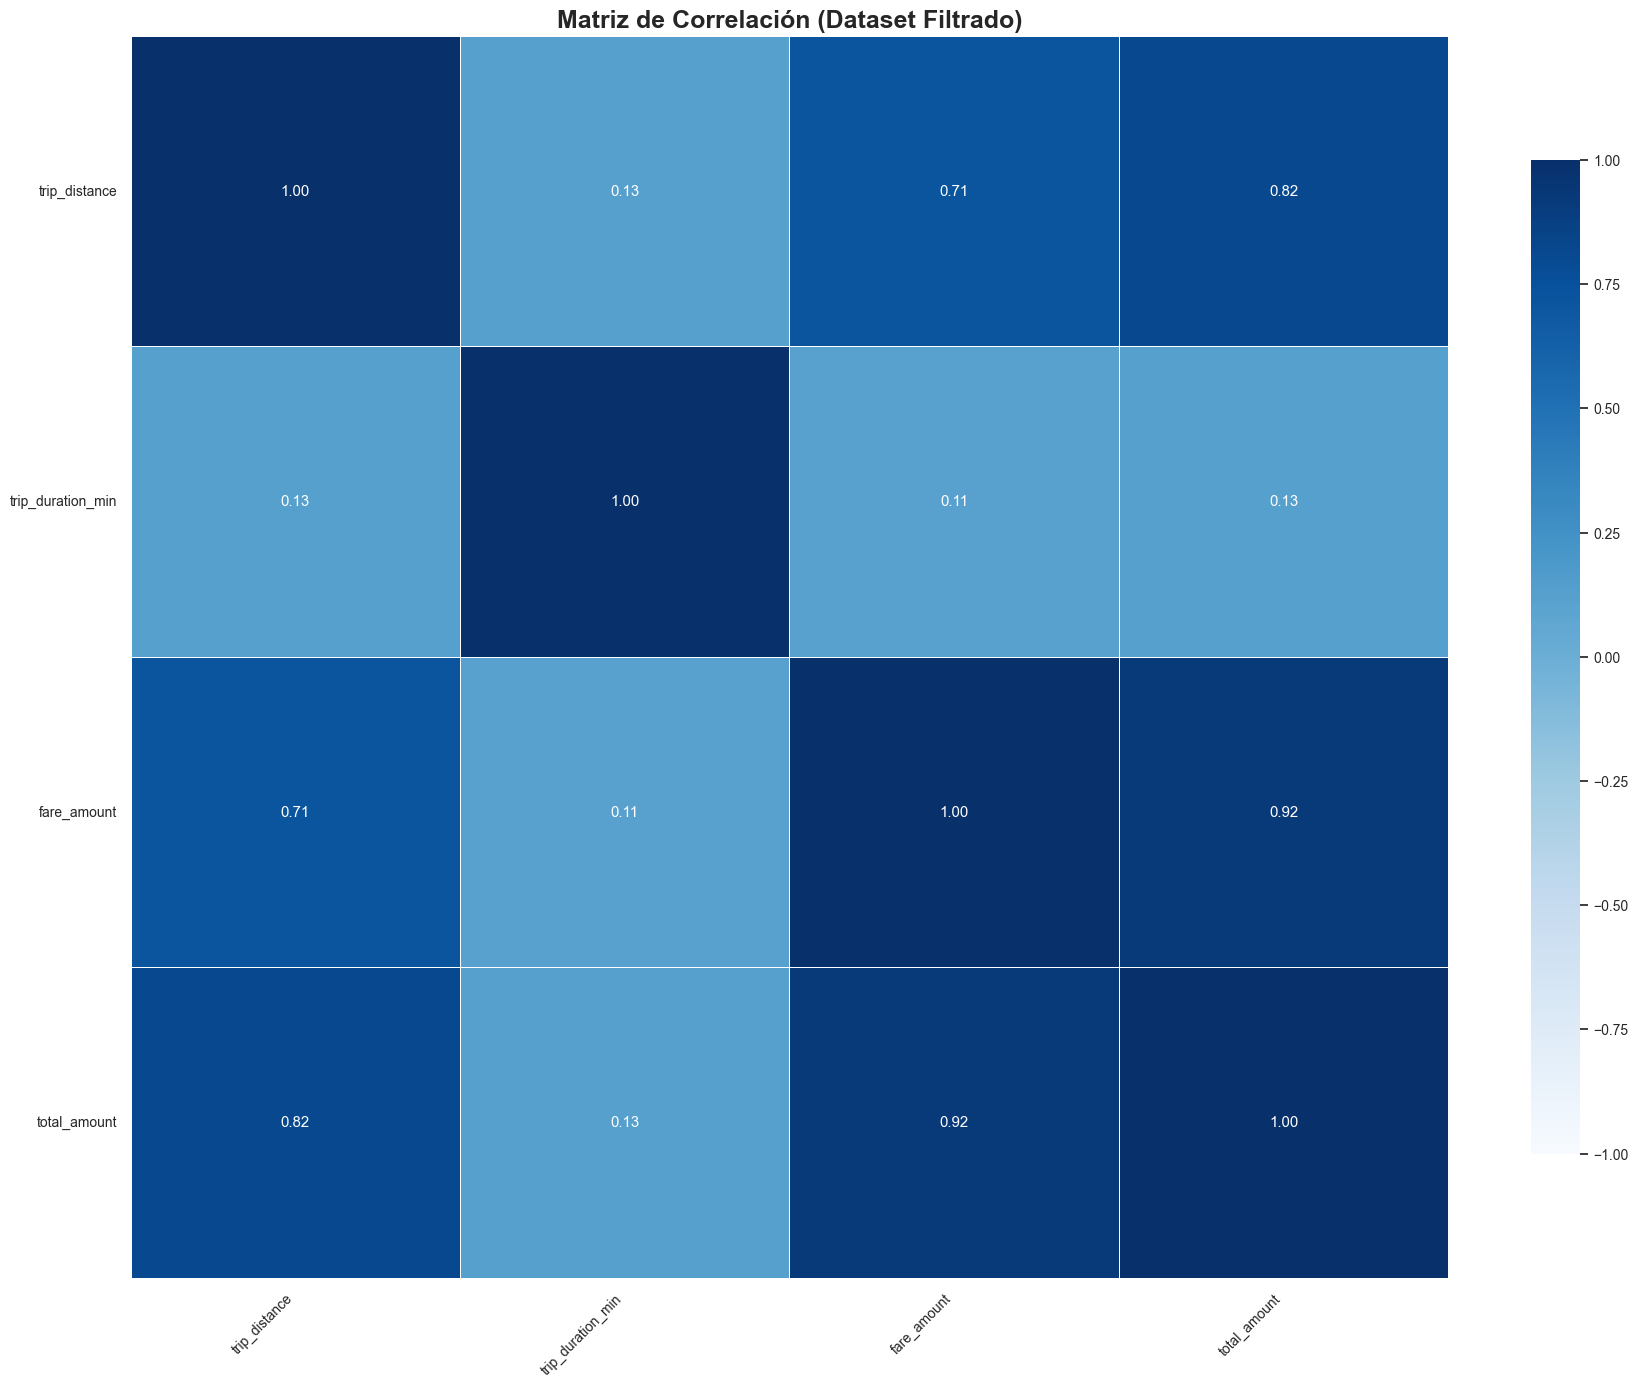

In [82]:
# Seleccionar columnas numéricas del DataFrame filtrado (df_trip_lows)
numeric_cols_for_corr = df_trip_lows.select_dtypes(include=[np.number]).columns
df_prep_for_corr = df_trip_lows[numeric_cols_for_corr].copy()

# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

plt.figure(figsize=(18, 14))
#sns.heatmap(corr, annot=True,cmap='Blues',fmt=".3f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación (Dataset Filtrado)", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

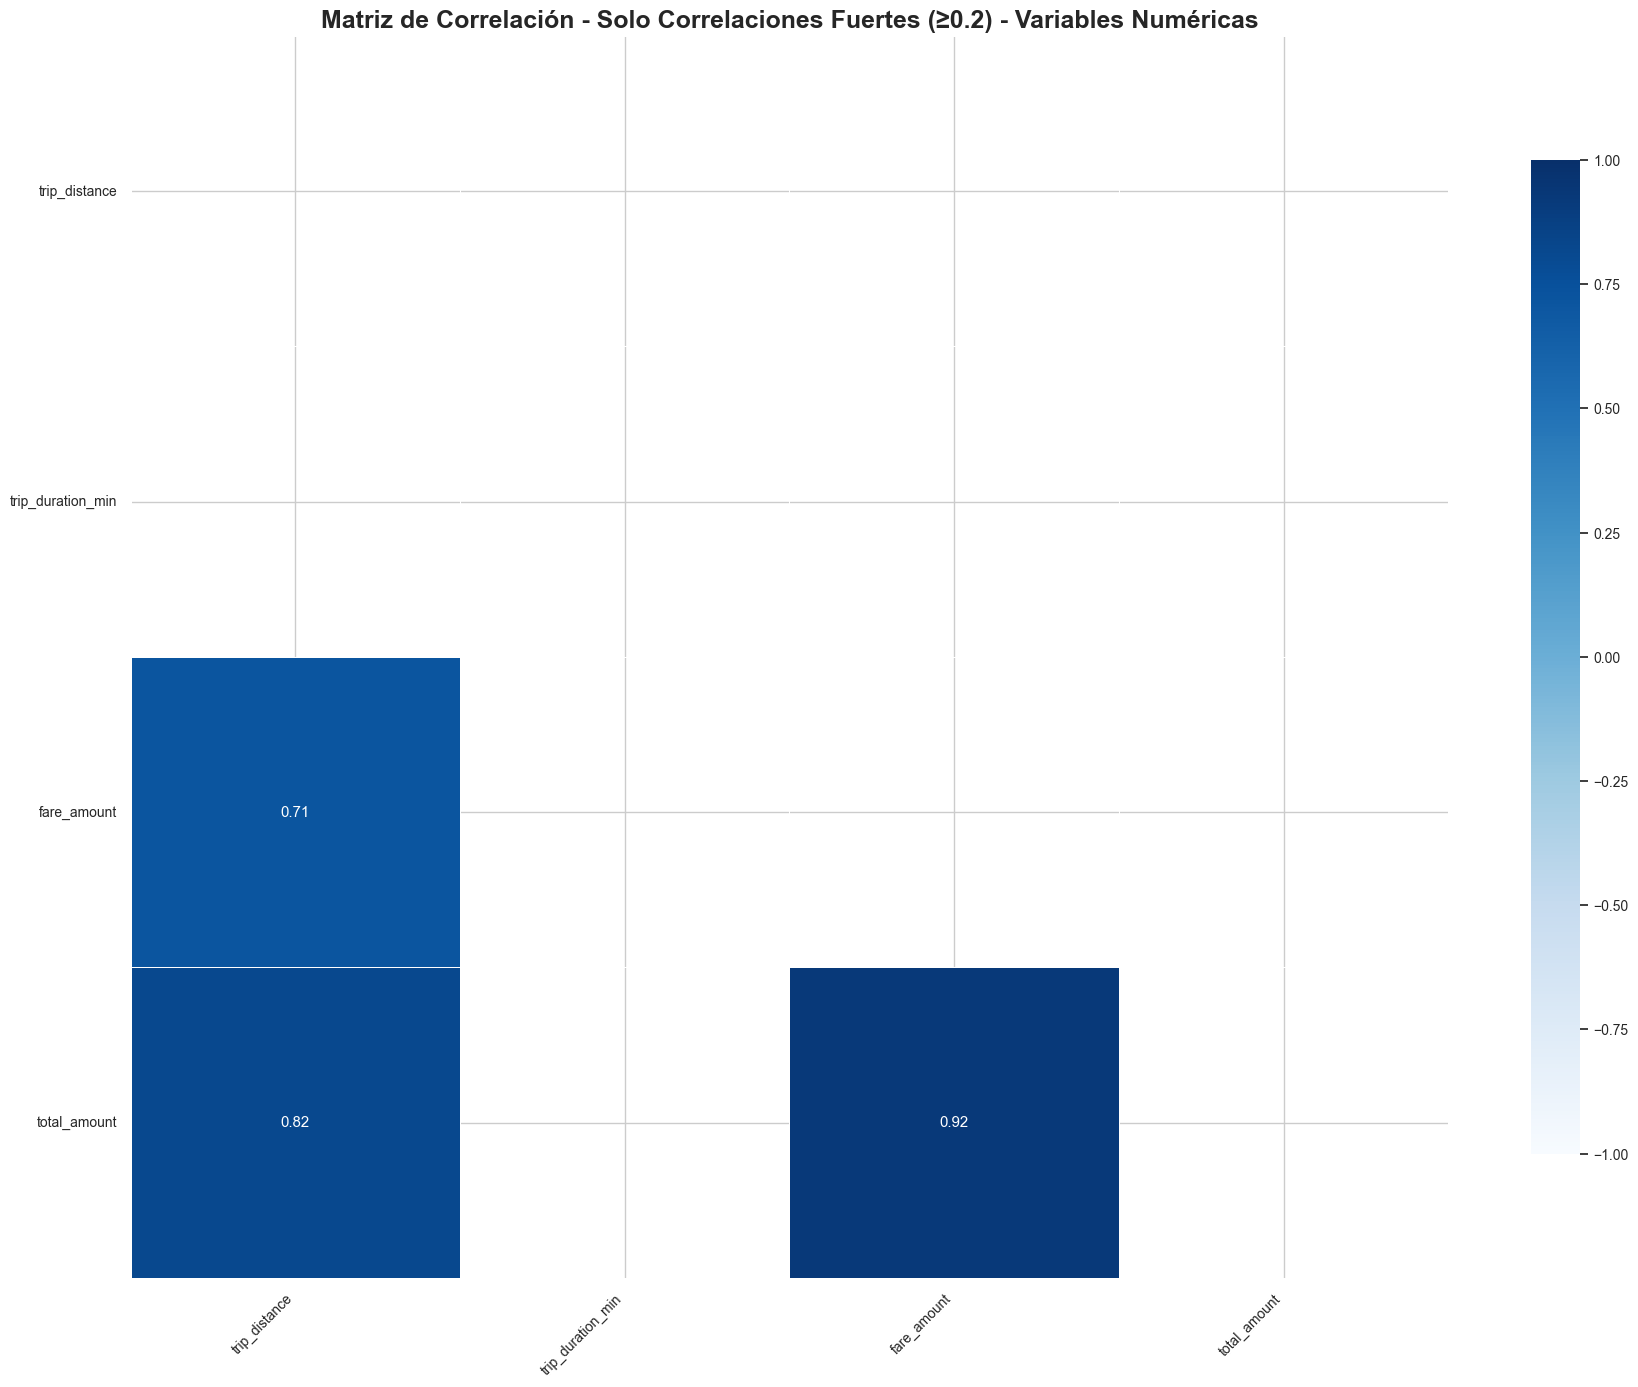

In [83]:
# Heatmap con máscara para correlaciones fuertes (≥0.2) - Dataset filtrado
mask = np.triu(np.ones_like(corr, dtype=bool)) | (np.abs(corr) < 0.2)
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f", mask=mask, 
            linewidths=.5, cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Solo Correlaciones Fuertes (≥0.2) - Variables Numéricas", 
          fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación de resultados:**
El dataset para predicción de trip_duration_min se ha exportado exitosamente como 'preparation_trip_green_tripdata_2025-06.parquet'. Este archivo completa la fase de Data Preparation proporcionando un dataset especializado para modelado temporal. Ambos datasets (total_amount y trip_duration) están ahora listos para la Fase 4 del CRISP-DM (Modeling), cada uno optimizado para sus respectivos objetivos predictivos con características seleccionadas, normalizadas y validadas estadísticamente.

In [84]:
# Define el nombre del archivo
datapreparation = 'preparation_trip_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_prep en formato Parquet
try:
    df_trip_lows.to_parquet(datapreparation, index=True) 
    print(f"DataFrame guardado exitosamente como '{datapreparation}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'preparation_trip_green_tripdata_2025-06.parquet'
